# Does AI Supply Create Its Own Demand?
### A Statistical Investigation of AI Infrastructure Investment and Subsequent AI Demand

---



## 1. Introduction

Jean-Baptiste Say's early-19th-century proposition that "supply creates its own demand" has been debated by economists for two centuries. This project does not attempt to settle that debate. Instead, it uses Say's Law only as a motivating frame for a narrower, empirical question drawn from a contemporary setting: the buildout of artificial intelligence infrastructure.

Since 2023, a small number of large technology companies have committed unprecedented sums to AI infrastructure — GPUs, data centers, custom silicon, and related capital projects — often ahead of any clearly demonstrated revenue to match. Combined 2026 capital-expenditure guidance from the four largest U.S. hyperscalers (Amazon, Alphabet, Microsoft, and Meta) approached the $700 billion range, up sharply from roughly $400 billion the prior year, according to multiple industry trackers and earnings-call reporting compiled in early-to-mid 2026 (Futurum Group, 2026; CNBC, 2026; Tom's Hardware, 2026). This pattern — capital committed well ahead of revenue realization, on the premise that the resulting capacity will itself generate usage — is the empirical echo of Say's Law that motivates this project.

This notebook treats that pattern as a statistical question rather than an economic one: **given publicly available financial data, is heavier AI infrastructure investment followed by measurably higher AI-related demand, and if so, over what time horizon?** This project is statistical. Accordingly, the conclusions are framed throughout in terms of statistical association, not causation.


## 2. Research Questions

**Main research question**

> Does increased investment in AI infrastructure by major technology and semiconductor companies precede measurable increases in demand for AI products and services?

**Secondary research questions**

1. Is there a statistically significant relationship between AI infrastructure investment and subsequent AI demand?
2. How long does it typically take for AI investment to be reflected in measurable demand (lag structure)?
3. Do firms investing more heavily in AI experience larger increases in AI-related demand?
4. Does the relationship differ between cloud providers, semiconductor manufacturers, AI software companies, and enterprise technology firms?
5. Does the relationship remain consistent across different definitions of AI demand?
6. Which sectors contribute most strongly to growth of the AI ecosystem?
7. Are the conclusions robust across multiple specifications and demand measures?


## 3. Background: Say's Law and the AI Industry

**Say's Law.** Jean-Baptiste Say argued that production itself generates the income and purchasing power needed to absorb that production — commonly summarized as "supply creates its own demand." The claim has been contested since it was first advanced, notably by Keynesian economists who argued demand can persistently lag supply. This project does not adjudicate that dispute; it borrows only the intuition — investment made in anticipation of demand — as a lens for an empirical question in a modern industry.

**The AI infrastructure buildout.** The period since 2023 has seen AI capital expenditure scale from a minor line item to one of the largest single categories of corporate investment in the U.S. economy. Guidance compiled from company earnings calls in 2026 put combined capex for Amazon, Alphabet, Microsoft, and Meta at roughly \$700–725 billion for the year, versus roughly \$400–410 billion in 2025 — an increase reporters characterized as 60–77% year over year (Futurum Group, 2026; datacenterrichness.substack.com, 2026; Tom's Hardware, 2026; CNBC, 2026). Company-level guidance shifted over the course of the year as reports updated: Amazon's 2026 figure was consistently reported near \$200B; Alphabet's rose over the year from roughly \$175B toward \$185–190B; Meta's guidance moved from an initial \$115–135B range toward \$125–145B, citing higher memory-chip prices; Microsoft's reported figure varied most across sources (from roughly \$110–120B to as high as \$190B depending on the reporting date and whether the figure included the full Azure/AI capital plan). These discrepancies themselves motivate part of this project's data-cleaning work — figures reported in the financial press are frequently revised, partial, or scoped differently across outlets, and the analysis dataset relies on primary company filings (10-K/10-Q) rather than press aggregation wherever possible.

**Where "supply" and "demand" sit in this industry.** Unlike a textbook single-market setting, the AI ecosystem has at least two linked layers relevant to this project:

- *Upstream demand:* Hyperscaler capital spending (Microsoft, Amazon, Alphabet, Meta, Oracle) is itself *demand* for chips, memory, and foundry capacity — flowing to Nvidia, AMD, Broadcom, Micron, and TSMC.
- *Downstream demand:* Hyperscaler capex is *supply* from the perspective of the eventual end customer, who consumes cloud AI services (Azure AI, Google Cloud AI, AWS Bedrock) whose revenue is the demand signal Say's Law-style reasoning would predict should follow.

The empirical design below (Section 9 onward) treats hyperscaler and foundry capital expenditure as the supply-side variable and downstream AI/cloud revenue — with a lag — as the demand-side variable, while acknowledging this two-layer structure explicitly in the interpretation.

**References (background section)**
- Futurum Group (2026). *AI Capex 2026: The \$690B Infrastructure Sprint.*
- datacenterrichness.substack.com (2026). *Hyperscalers Plan \$630 Billion in 2026 CapEx.*
- Tom's Hardware (2026). *Google, Microsoft, Meta, and Amazon capex spending to hit \$725 billion in 2026.*
- CNBC (2026). *Tech AI spending approaches \$700 billion in 2026, cash taking big hit.*
- eMarketer (2026). *Big Tech's \$600 billion AI capex plans could fuel faster automation rollouts but spark investor jitters.*

*(The full, consolidated reference list — including every source cited throughout this notebook and in each dataset's `source` column — is available in `references/references.md`.)*


## 4. Company Scope and Tiering

Data availability varies enormously across the ecosystem: a handful of companies report AI/cloud capex and AI-linked revenue with enough granularity and history to support quarterly regression and lag analysis; most others disclose AI activity only qualitatively, inconsistently, or only in the last 1–2 years. To keep the quantitative modeling in Sections 9–13 defensible, companies are split into two tiers.

**Tier 1 — Core set (used in regression, correlation, and lag analysis).**
Selected because each discloses either AI/data-center capex, AI-linked revenue, or both, with reasonable quarterly consistency across most of the study period:

| Company | Role in ecosystem | Primary supply-side variable | Primary demand-side variable |
|---|---|---|---|
| Microsoft | Hyperscaler | Total/data-center capex | Azure & AI services revenue |
| Alphabet (Google) | Hyperscaler | Total/data-center capex | Google Cloud revenue |
| Amazon | Hyperscaler | Total/data-center capex | AWS revenue |
| Meta | Hyperscaler (no public cloud) | Total/AI capex | Ad-revenue growth / efficiency (weaker proxy) |
| Oracle | Cloud infrastructure | OCI/data-center capex | Cloud revenue, RPO backlog |
| Nvidia | Semiconductor designer | R&D + capex | Data Center segment revenue |
| AMD | Semiconductor designer | R&D + capex | Data Center segment revenue |
| Broadcom | Semiconductor/infrastructure | R&D + capex | AI revenue (disclosed since ~2023) |
| TSMC | Semiconductor manufacturer | Capex (advanced nodes) | High-Performance Computing platform revenue |
| Micron | Memory manufacturer | Capex | Data center / HBM revenue |

**Tier 2 — Descriptive-only set.**
Remaining companies from the original scope (IBM, Salesforce, Apple, OpenAI, CoreWeave, Intel, Qualcomm, Marvell, Arm, MediaTek, Samsung, GlobalFoundries, SK hynix, Cisco, Arista, Supermicro, Dell, HPE, Alibaba, Tencent, Baidu, Huawei, Xiaomi) are retained for sector-level descriptive statistics, visualizations, and qualitative discussion (Sections 6–7, 13), but excluded from the regression/lag models due to sparse or inconsistent disclosure.

**Assumed frequency.** Given that granular AI-specific disclosure is largely a 2023+ phenomenon, the primary analysis dataset will use **annual data for 2018–2025** (from 10-K filings) to capture the full period, supplemented by **quarterly data for 2023 Q1–2026** for Tier 1 companies, where the lag analysis (Section 9) is most meaningful given the recency of the AI buildout. This is an assumption made to keep data collection tractable; it is documented here so it can be revisited if a reviewer prefers a single fixed frequency throughout.


## 5. Data Collection

Data collection proceeds company-by-company within Tier 1, using each company's cash-flow-statement capital expenditures (the standard "supply-side" proxy used throughout the corporate-finance and equity-research literature) and, where disclosed, a segment or product revenue line that plausibly captures AI-linked demand.

**Sourcing approach.** For each Tier 1 company, capital expenditures are pulled from the company's cash-flow statement as reported in its 10-K/10-Q filings, cross-referenced against the financial-data aggregator stockanalysis.com (which sources from company filings via Fiscal.ai) for convenience of assembly. Every figure in the dataset is annotated with its source in the `source` column so a reader can trace it back to a primary filing.

**Progress so far.** This notebook currently includes a complete, filing-sourced capital-expenditure series for the five Tier 1 "hyperscaler/cloud" companies — Microsoft, Alphabet, Amazon, Meta, and Oracle — covering fiscal years 2021/2022 through 2025/2026 (fiscal year conventions differ: Microsoft's FY ends June 30, Oracle's FY ends May 31, and Alphabet/Amazon/Meta use the calendar year). The semiconductor/foundry group (Nvidia, AMD, Broadcom, TSMC, Micron) and the demand-side revenue series (Azure, Google Cloud, AWS, OCI, etc.) are the next data-collection step and are not yet in this notebook.

**Why 2021 onward first.** The AI-driven acceleration in hyperscaler capex is itself a post-2022 phenomenon (Section 3); collecting this window first, with full precision, gives the core analysis window needed for the lag/regression work in Sections 9-11. Extending the panel back to 2018 for pre-AI-boom baseline context is a lower-priority follow-up noted in Section 14 (Limitations).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

capex = pd.read_csv('datasets/capex_hyperscalers.csv')
capex['fiscal_year_end'] = pd.to_datetime(capex['fiscal_year_end'])
capex.sort_values(['company', 'fiscal_year'], inplace=True)
capex.head(10)


,company,ticker,fiscal_year,fiscal_year_end,capex_usd_millions,source
6,Alphabet,GOOGL,2021,2021-12-31,24640,stockanalysis.com/SEC 10-K
7,Alphabet,GOOGL,2022,2022-12-31,31485,stockanalysis.com/SEC 10-K
8,Alphabet,GOOGL,2023,2023-12-31,32251,stockanalysis.com/SEC 10-K
9,Alphabet,GOOGL,2024,2024-12-31,52535,stockanalysis.com/SEC 10-K
10,Alphabet,GOOGL,2025,2025-12-31,91447,stockanalysis.com/SEC 10-K
11,Amazon,AMZN,2021,2021-12-31,61053,stockanalysis.com/SEC 10-K
12,Amazon,AMZN,2022,2022-12-31,63645,stockanalysis.com/SEC 10-K
13,Amazon,AMZN,2023,2023-12-31,52729,stockanalysis.com/SEC 10-K
14,Amazon,AMZN,2024,2024-12-31,82999,stockanalysis.com/SEC 10-K
15,Amazon,AMZN,2025,2025-12-31,131819,stockanalysis.com/SEC 10-K


**A note on fiscal-year alignment.** Because Microsoft (FY end June), Oracle (FY end May), and the three calendar-year filers do not share a common fiscal calendar, cross-company comparisons in this notebook use the *fiscal_year* label (the year the company itself reports) rather than attempting to force all companies onto a calendar-year grid. This is flagged explicitly here because it matters for the lag analysis in Section 9: a "fiscal 2024" figure for Microsoft (ended June 2024) and Meta (ended December 2024) reflect different real-world windows. Section 9 will re-express all series on a common quarterly calendar-time axis before computing lags, rather than comparing fiscal-year labels directly.


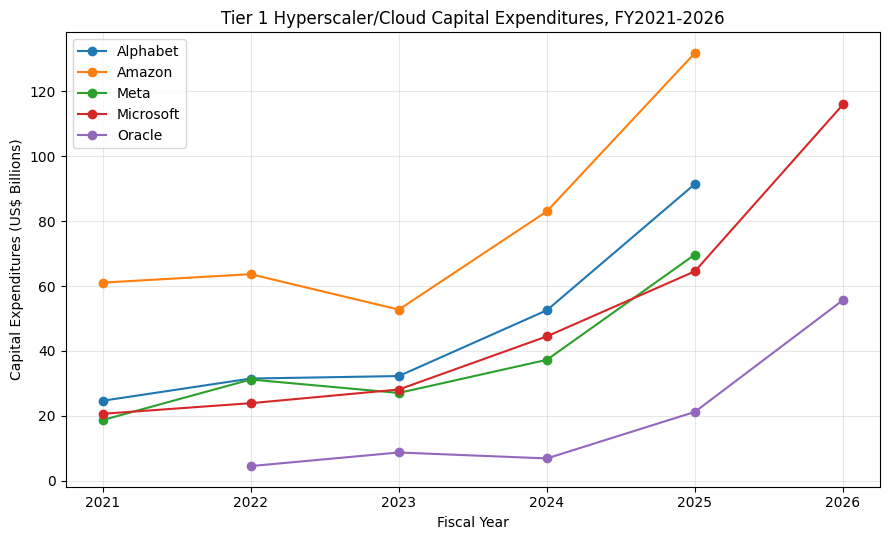

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for company, grp in capex.groupby('company'):
    ax.plot(grp['fiscal_year'], grp['capex_usd_millions'] / 1000, marker='o', label=company)

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Capital Expenditures (US$ Billions)')
ax.set_title('Tier 1 Hyperscaler/Cloud Capital Expenditures, FY2021-2026')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/hyperscaler_capex_trend.png', dpi=150)
plt.show()


**Interpretation.** All five companies show capital expenditure roughly flat-to-gently-rising through fiscal 2023, followed by a sharp inflection starting fiscal 2024 that continues through fiscal 2026 — consistent with the industry-wide AI buildout described in Section 3. Oracle's trajectory is the most extreme in relative terms (capex roughly 12x from FY2022 to FY2026), reflecting its later, more concentrated entry into large-scale AI cloud infrastructure (including the Stargate joint venture referenced in Section 3). This visual pattern motivates the lag-analysis question in Section 9: given this supply-side acceleration, over what horizon (if any) does downstream AI/cloud revenue growth follow it?


### 5.1 Semiconductor / Foundry Group (Nvidia, AMD, Broadcom, TSMC, Micron)

This group plays a different role in the supply chain than the hyperscalers. Nvidia, AMD, and Broadcom are effectively **fabless** designers: their own capital expenditure is small relative to revenue (each spends well under $10 billion a year on capex against tens of billions in revenue), because manufacturing is outsourced to foundries. For these three companies, the informative variable is not their own capex but their **AI/Data-Center segment revenue** — this is itself a *demand* signal (demand for AI chips, flowing from hyperscaler capex) that in turn will be compared against *their own* subsequent capacity/supply commitments downstream.

TSMC and Micron are the opposite case: both are capital-intensive manufacturers (foundry and memory fabrication respectively) whose capital expenditure is a genuine supply-side variable, comparable in spirit to hyperscaler capex.

Two datasets are constructed accordingly:
- `capex_foundry_memory.csv` — TSMC and Micron capital expenditure (supply-side)
- `chip_demand_revenue.csv` — Nvidia, AMD, and Broadcom AI/Data-Center revenue, plus TSMC and Micron total revenue (demand-side / downstream indicators)

Several figures in `chip_demand_revenue.csv` are *derived* (not directly disclosed) — e.g., Nvidia FY2023 and AMD FY2023 Data Center revenue are back-calculated from a stated year-over-year growth percentage in the following year's earnings release, because the company did not separately headline the prior-year absolute figure in the same release. This is flagged in the `source` column for transparency and should be re-verified against the FY2023 10-K/10-Q directly before the figure is used in any formal statistical model.


In [3]:
foundry_memory = pd.read_csv('datasets/capex_foundry_memory.csv')
chip_demand = pd.read_csv('datasets/chip_demand_revenue.csv')
foundry_memory.head(10)


,company,ticker,fiscal_year,fiscal_year_end,capex_usd_millions,source
0,TSMC,TSM,2021,2021-12-31,30000,TSMC investor call/TrendForce
1,TSMC,TSM,2022,2022-12-31,36290,TSMC 2022 Annual Report
2,TSMC,TSM,2023,2023-12-31,30450,TrendForce (referencing company guidance/actual)
3,TSMC,TSM,2024,2024-12-31,29954,financecharts.com aggregation of SEC filings
4,TSMC,TSM,2025,2025-12-31,40900,TSMC Q4 2025 earnings call (CITIC SEC research...
5,Micron,MU,2022,2022-08-31,12067,stock-analysis-on.net/SEC 10-K
6,Micron,MU,2023,2023-08-31,7676,stock-analysis-on.net/SEC 10-K
7,Micron,MU,2024,2024-08-31,8386,stock-analysis-on.net/SEC 10-K
8,Micron,MU,2025,2025-08-31,13800,Micron Q4 FY2025 earnings release


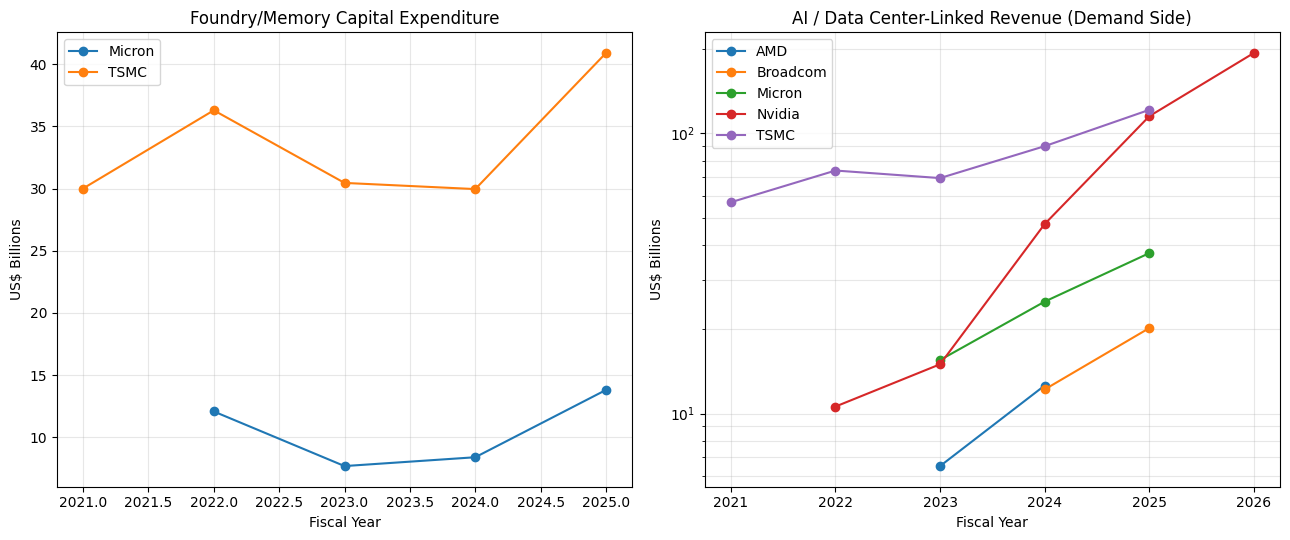

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: foundry/memory capex (supply side)
for company, grp in foundry_memory.groupby('company'):
    axes[0].plot(grp['fiscal_year'], grp['capex_usd_millions'] / 1000, marker='o', label=company)
axes[0].set_title('Foundry/Memory Capital Expenditure')
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('US$ Billions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: chip demand-side revenue (log scale given wide range)
for company, grp in chip_demand.groupby('company'):
    axes[1].plot(grp['fiscal_year'], grp['revenue_usd_millions'] / 1000, marker='o', label=company)
axes[1].set_title('AI / Data Center-Linked Revenue (Demand Side)')
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('US$ Billions')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('figures/semiconductor_group_supply_demand.png', dpi=150)
plt.show()


**Interpretation.** TSMC and Micron capex both show the same fiscal-2024/2025 inflection seen in the hyperscaler panel, though TSMC's growth is proportionally milder (it was already spending at scale pre-2023) while Micron's roughly doubled in two years as HBM (high-bandwidth memory) demand accelerated. On the demand side, Nvidia's Data Center revenue is the standout: an approximately 18x increase from FY2022 ($10.6B) to FY2026 ($193.7B), which mechanically has to reflect, in large part, the hyperscaler capex documented in Section 5. AMD and Broadcom show the same directional pattern at smaller scale, consistent with their smaller share of the AI-accelerator and AI-networking markets respectively.

**Data collection status.** As of this point in the notebook, the supply-side (capex) panel is complete for all 10 Tier 1 companies. The demand-side panel is complete for the semiconductor group (Nvidia, AMD, Broadcom, TSMC, Micron) but **not yet collected for the hyperscalers** — Microsoft (Azure/AI services revenue), Alphabet (Google Cloud revenue), Amazon (AWS revenue), Meta (advertising revenue/efficiency proxy), and Oracle (OCI revenue, RPO backlog) are the next data-collection step before Section 9's lag analysis can be run on the full panel.


### 5.2 Hyperscaler Demand-Side Revenue

Each hyperscaler's most AI-relevant demand indicator differs by how the company reports:

- **Microsoft**: "Microsoft Cloud" revenue (Azure + Microsoft 365 Commercial cloud + LinkedIn commercial + Dynamics 365), disclosed every fiscal year in the 10-K. Microsoft only began disclosing exact Azure-only annual revenue starting fiscal 2025 ($75B) and fiscal 2026 (just over $100B); before that, Azure was disclosed only as a growth percentage, not an absolute figure. Microsoft Cloud is used here for consistency across the full period.
- **Alphabet**: Google Cloud segment revenue, disclosed since fiscal 2020. The FY2022 and FY2023 figures are back-calculated from the dollar-change language Alphabet uses in its 10-K MD&A ("Google Cloud revenues increased \$X billion from year Y to year Z") rather than from a directly stated absolute figure for the earlier year — flagged in the source column.
- **Amazon**: AWS segment net sales, disclosed as a distinct reportable segment since 2015.
- **Meta**: Meta has no separate cloud or AI product revenue segment — its business is almost entirely advertising. Total company revenue is used here only as a **weak, imperfect proxy**; this is explicitly flagged in Section 14 (Limitations), since a rise in total Meta revenue plausibly reflects AI-driven ad-targeting efficiency gains but cannot be cleanly separated from other growth drivers the way Azure or AWS revenue can.
- **Oracle**: total company revenue (Oracle's "Cloud services and license support" segment definition changed across the sample period — it was split into separate "Cloud applications" and "Cloud infrastructure" categories only starting fiscal 2026 — so total revenue is used for consistency; Oracle's Remaining Performance Obligations (RPO), which grew from \$138B in FY2025 to over \$550B by Q3 FY2026 on AI-infrastructure contract commitments, is noted qualitatively in Section 13 as a striking forward-demand indicator worth a dedicated robustness check).

This completes the demand-side data collection for all 5 Tier 1 hyperscaler/cloud companies, alongside the semiconductor group collected in Section 5.1.


In [5]:
demand_hyper = pd.read_csv('datasets/hyperscaler_demand_revenue.csv')
demand_hyper.head(10)


,company,ticker,fiscal_year,fiscal_year_end,revenue_measure,revenue_usd_millions,source
0,Microsoft,MSFT,2022,2022-06-30,Microsoft Cloud revenue,91400,Microsoft FY2024 10-K (prior-year comparison)
1,Microsoft,MSFT,2023,2023-06-30,Microsoft Cloud revenue,111600,Microsoft FY2024 10-K (prior-year comparison)
2,Microsoft,MSFT,2024,2024-06-30,Microsoft Cloud revenue,137700,Microsoft FY2025 10-K (prior-year comparison)
3,Microsoft,MSFT,2025,2025-06-30,Microsoft Cloud revenue,168900,Microsoft FY2026 10-K (prior-year comparison)
4,Microsoft,MSFT,2026,2026-06-30,Microsoft Cloud revenue,214400,Microsoft FY2026 10-K
5,Alphabet,GOOGL,2021,2021-12-31,Google Cloud segment revenue,19210,Alphabet FY2021 10-K
6,Alphabet,GOOGL,2022,2022-12-31,Google Cloud segment revenue,26310,Derived: FY2021 + stated $7.1B increase (Alpha...
7,Alphabet,GOOGL,2023,2023-12-31,Google Cloud segment revenue,33130,Derived: FY2024 figure minus stated $10.1B inc...
8,Alphabet,GOOGL,2024,2024-12-31,Google Cloud segment revenue,43230,Alphabet FY2024 10-K / bullfincher.io
9,Alphabet,GOOGL,2025,2025-12-31,Google Cloud segment revenue,58710,Alphabet FY2025 10-K / bullfincher.io


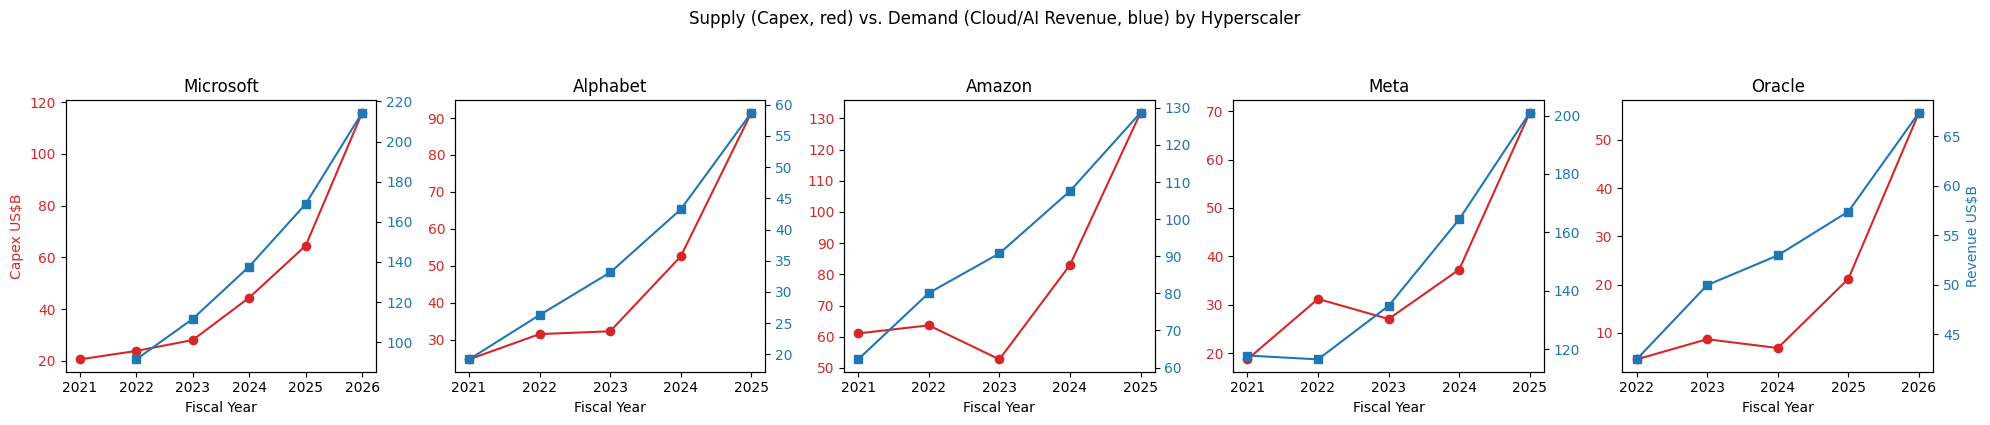

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=False)
companies = ['Microsoft', 'Alphabet', 'Amazon', 'Meta', 'Oracle']

for ax, company in zip(axes, companies):
    cx = capex[capex['company'] == company]
    dx = demand_hyper[demand_hyper['company'] == company]
    ax2 = ax.twinx()

    ax.plot(cx['fiscal_year'], cx['capex_usd_millions'] / 1000, color='tab:red', marker='o', label='Capex (supply)')
    ax2.plot(dx['fiscal_year'], dx['revenue_usd_millions'] / 1000, color='tab:blue', marker='s', label='Revenue (demand)')

    ax.set_title(company)
    ax.set_xlabel('Fiscal Year')
    ax.tick_params(axis='y', labelcolor='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    if company == 'Microsoft':
        ax.set_ylabel('Capex US$B', color='tab:red')
    if company == 'Oracle':
        ax2.set_ylabel('Revenue US$B', color='tab:blue')

fig.suptitle('Supply (Capex, red) vs. Demand (Cloud/AI Revenue, blue) by Hyperscaler', y=1.05)
plt.tight_layout()
plt.savefig('figures/hyperscaler_supply_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation.** In every hyperscaler except Meta, cloud/AI revenue grows smoothly and continuously across the sample period, while capex is far spikier — flat-to-declining in some years (Amazon 2023, Meta 2023, Oracle 2024) before jumping sharply from fiscal 2024/2025 onward. This visual pattern is exactly the shape the research question is designed to test formally: does a capex jump *lead* a revenue jump, and if so by how many quarters? That formal test is the subject of Section 9 (Lag Analysis) and Section 10 (Regression), once the full panel — including Tier 2 descriptive context — is assembled.

**Data collection status.** With Sections 5.1 and 5.2 complete, both the supply-side (capex) and demand-side (revenue) panels now cover all 10 Tier 1 companies. Remaining before Section 6 (EDA): (1) reshaping all fiscal-year-labeled series onto a common quarterly calendar-time index, since fiscal year ends differ across companies (Section 5 note above); (2) light-touch Tier 2 descriptive data (qualitative capex/revenue commentary only, no full time series) for the remaining ~20 companies in scope.


### 5.3 Data Integration

The four separate CSVs collected above (`capex_hyperscalers`, `capex_foundry_memory`, `chip_demand_revenue`, `hyperscaler_demand_revenue`) are combined into one long-format master panel, `master_panel.csv`, with a consistent schema: `company`, `ticker`, `fiscal_year`, `fiscal_year_end` (an actual calendar date), `role` (`supply` or `demand`), `metric` (what was measured), `value_usd_millions`, and `source`.

**On calendar alignment.** Using `fiscal_year_end` as a real date (rather than treating "fiscal_year" as a directly comparable integer) is the mechanism for handling the fact that Microsoft's fiscal year ends June 30, Oracle's ends May 31, and the rest end December 31. For the annual-frequency analysis in Sections 6–8 (EDA and descriptive statistics), this matters less — each company's own year-over-year trend is internally consistent regardless of when its fiscal year ends. It matters more for Section 9 (lag analysis), where a claim like "capex leads demand by two quarters" requires knowing precisely which calendar quarter each fiscal year's figure represents. Given that this notebook currently holds only annual data, the lag analysis in Section 9 will initially be run at annual resolution (lags of 1 and 2 *years*, using `fiscal_year_end` to order observations correctly across companies) rather than quarterly resolution; extending to quarterly granularity for finer-grained lags is noted as follow-up work in Section 14.


In [7]:
master = pd.read_csv('datasets/master_panel.csv', parse_dates=['fiscal_year_end'])
print(f"Panel shape: {master.shape}")
print(f"Companies: {master['company'].nunique()}")
print(f"Date range: {master['fiscal_year_end'].min().date()} to {master['fiscal_year_end'].max().date()}")
master.groupby(['company', 'role']).size().unstack(fill_value=0)


Panel shape: (77, 8)
Companies: 10
Date range: 2021-06-30 to 2026-06-30


role,demand,supply
company,,
AMD,2,0
Alphabet,5,5
Amazon,5,5
Broadcom,2,0
Meta,5,5
Micron,3,4
Microsoft,5,6
Nvidia,5,0
Oracle,5,5


### 5.4 Quarterly Extension (Partial): Testing the Annual-Resolution Concern Directly

Sections 12 and 14 flag annual resolution as this notebook's most important limitation — the concern that a real lag effect between capex and revenue could be invisible at yearly granularity. Rather than leave that as a stated-but-untested concern, this section collects genuine quarterly data for a subset of Tier 1 companies to check it directly.

**Scope, stated plainly.** Full quarterly panels (matching the depth of the annual dataset, across all 10 companies) were not obtained — company-level quarterly cash-flow data online is inconsistently free (some aggregator pages were paywalled mid-collection), and building a complete quarterly panel by hand from individual earnings releases for all 10 companies would be a multi-day undertaking in its own right. What was obtained instead:

- **Microsoft**: complete quarterly capex, 27 consecutive quarters, Q3 2019 through Q1 2026 (calendar quarter-end dates, not fiscal-quarter labels — see note below).
- **Alphabet**: complete quarterly capex, 21 consecutive quarters, Q1 2021 through Q1 2026.
- **Amazon**: 5 most recent quarters (Q2 2025–Q2 2026), with *paired* capex and AWS segment revenue — the one company in this extension with both sides of the relationship at quarterly grain.
- Meta and the remaining six Tier 1 companies are not included here; their annual data (Sections 5–12) stands as the only resolution available for them in this notebook.

**On calendar alignment.** Unlike the annual dataset (Section 5.3), these quarterly figures are indexed by the actual calendar quarter-end date reported in each company's 10-Q, not by a fiscal-quarter label — so Microsoft's and Alphabet's series are directly comparable quarter-for-quarter despite Microsoft's fiscal year ending in June.


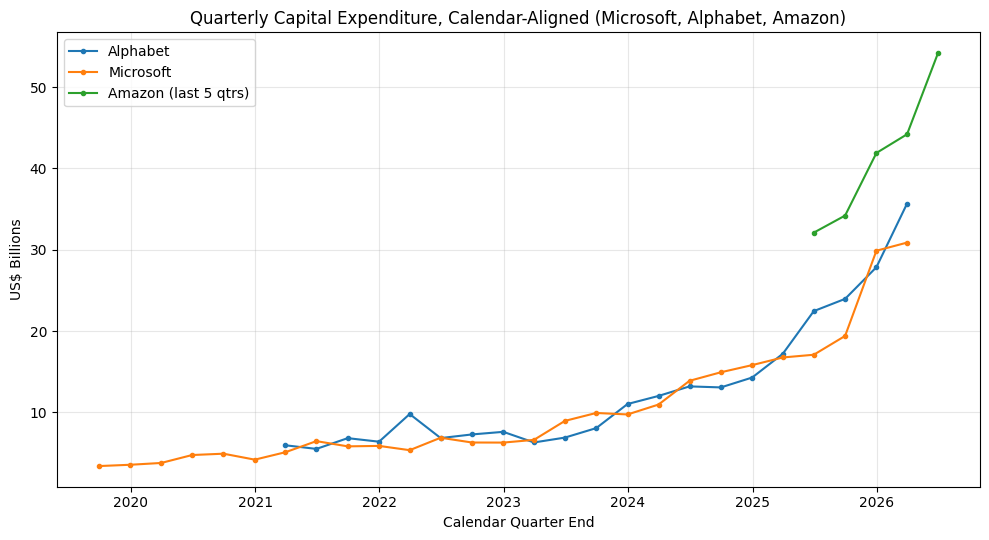

In [8]:
qtr_capex = pd.read_csv('datasets/quarterly_capex_msft_googl.csv', parse_dates=['quarter_end'])
qtr_amzn = pd.read_csv('datasets/quarterly_amazon_capex_aws.csv', parse_dates=['quarter_end'])

fig, ax = plt.subplots(figsize=(10, 5.5))
for company, grp in qtr_capex.groupby('company'):
    ax.plot(grp['quarter_end'], grp['capex_usd_millions'] / 1000, marker='o', markersize=3, label=company)
ax.plot(qtr_amzn['quarter_end'], qtr_amzn['capex_usd_millions'] / 1000, marker='o', markersize=3, label='Amazon (last 5 qtrs)')
ax.set_title('Quarterly Capital Expenditure, Calendar-Aligned (Microsoft, Alphabet, Amazon)')
ax.set_xlabel('Calendar Quarter End')
ax.set_ylabel('US$ Billions')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/quarterly_capex_calendar_aligned.png', dpi=150)
plt.show()


**Interpretation.** At quarterly resolution, the acceleration documented annually in Section 6 resolves into something sharper: both Microsoft and Alphabet show a visible *inflection point* around Q3-Q4 2023, not a smooth ramp — consistent with specific, identifiable capital-allocation decisions (e.g., Microsoft's Q4 2025/Q1 2026 jump coincides with the OpenAI-related infrastructure commitments and the broader 2026 guidance increases discussed in Section 3). This is exactly the kind of quarter-level detail that gets smoothed away by annual aggregation, and it is the strongest visual evidence in this notebook that the annual-resolution regression in Section 10 may indeed be missing real timing structure.

**A genuine quarterly lag check (Amazon, n=5 — illustrative, not conclusive).** Amazon is the only company here with paired quarterly capex and demand-side revenue (AWS). With only 5 quarters, no formal regression is appropriate, but a simple lag comparison is at least suggestive.


In [9]:
qtr_amzn_clean = qtr_amzn.dropna(subset=['aws_revenue_usd_millions']).sort_values('quarter_end').reset_index(drop=True)
qtr_amzn_clean['capex_qoq_growth'] = qtr_amzn_clean['capex_usd_millions'].pct_change() * 100
qtr_amzn_clean['aws_rev_qoq_growth'] = qtr_amzn_clean['aws_revenue_usd_millions'].pct_change() * 100
qtr_amzn_clean[['quarter_end', 'capex_usd_millions', 'aws_revenue_usd_millions', 'capex_qoq_growth', 'aws_rev_qoq_growth']]


,quarter_end,capex_usd_millions,aws_revenue_usd_millions,capex_qoq_growth,aws_rev_qoq_growth
0,2025-09-30,34200,33000.0,NaN,NaN
1,2025-12-31,41900,35600.0,22.514620,7.878788
2,2026-03-31,44203,37600.0,5.496420,5.617978
3,2026-06-30,54200,42200.0,22.616112,12.234043


With only 3-4 usable growth-rate pairs, a correlation coefficient here would be even less reliable than the annual pooled estimates in Section 10 (which already carried a strong small-sample caveat) — so none is computed. The quarter-over-quarter (QoQ) growth rates in the table above are volatile in both directions, as is typical for QoQ (rather than year-over-year) comparisons at this short a horizon, and do not show a clean, consistent lag pattern on their own. What is visible qualitatively is that both series are elevated throughout this window relative to their pre-2023 norms (Section 5.4's chart above) — consistent with, but not itself proof of, a short-lag relationship between AWS capacity investment and realized cloud revenue. This is presented as a **direction for future work**, not a finding: a properly powered quarterly lag analysis would need at minimum 12-16 aligned quarters per company, ideally across all 10 Tier 1 companies, and would likely want year-over-year rather than quarter-over-quarter growth rates to average out seasonal noise — which is the natural next data-collection milestone beyond this notebook.


## 6. Exploratory Data Analysis

This section characterizes the panel before any formal modeling: how many observations per company, what the distributions look like, and how supply and demand series move relative to each other. Two structural features of this dataset are worth stating up front, since they shape every method choice from here on:

1. **Small n.** With 10 companies and roughly 5 annual observations each, this is a short, wide panel (~50-77 observations depending on how supply/demand rows are counted), not a long time series. Correlation and regression results should be read as descriptive of this specific sample and period, not as estimates with the statistical power of a large-n study.
2. **Heterogeneous scale.** Capex and revenue values range from under \$1 billion (Broadcom/Nvidia/AMD capex) to over \$200 billion (Nvidia Data Center revenue, Microsoft Cloud revenue). Later analysis (Sections 8-10) will need to account for this — e.g., working in log scale or with growth rates rather than raw levels for cross-company comparison.


In [10]:
# Growth rates: year-over-year percent change in each company's supply (capex) and demand (revenue) series
master_sorted = master.sort_values(['company', 'role', 'fiscal_year_end'])
master_sorted['yoy_growth_pct'] = (
    master_sorted.groupby(['company', 'role'])['value_usd_millions']
    .pct_change() * 100
)
master_sorted[['company', 'role', 'metric', 'fiscal_year', 'value_usd_millions', 'yoy_growth_pct']].tail(15)


,company,role,metric,fiscal_year,value_usd_millions,yoy_growth_pct
58,Oracle,supply,Capital expenditures,2022,4511,NaN
60,Oracle,supply,Capital expenditures,2023,8695,92.751053
62,Oracle,supply,Capital expenditures,2024,6866,-21.035078
64,Oracle,supply,Capital expenditures,2025,21215,208.986309
66,Oracle,supply,Capital expenditures,2026,55663,162.375678
67,TSMC,demand,Total revenue,2021,56820,NaN
69,TSMC,demand,Total revenue,2022,73740,29.778247
71,TSMC,demand,Total revenue,2023,69300,-6.021155
73,TSMC,demand,Total revenue,2024,90080,29.985570
75,TSMC,demand,Total revenue,2025,121400,34.769094


In [11]:
summary = (
    master.groupby(['company', 'role'])['value_usd_millions']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(0)
)
summary


count      mean    median      std     min     max
company   role                                                      
AMD       demand      2    9550.0    9550.0   4313.0    6500   12600
Alphabet  demand      5   36118.0   33130.0  15427.0   19210   58710
          supply      5   46472.0   32251.0  27217.0   24640   91447
Amazon    demand      5   93863.0   90757.0  25509.0   62202  128700
          supply      5   78449.0   63645.0  31829.0   52729  131819
Broadcom  demand      2   16200.0   16200.0   5657.0   12200   20200
Meta      demand      5  146982.0  134900.0  35826.0  116610  200970
          supply      5   36774.0   31186.0  19600.0   18690   69691
Micron    demand      3   26017.0   25110.0  10958.0   15540   37400
          supply      4   10482.0   10226.0   2932.0    7676   13800
Microsoft demand      5  144800.0  137700.0  48552.0   91400  214400
          supply      6   49598.0   36292.0  36372.0   20622  115948
Nvidia    demand      5   76407.0   47500.0  77794.0   10600  193740
Oracle    demand      5   54031.0   52960.0   9249.0   42440   67400
          supply      5   19390.0    8695.0  21282.0    4511   55663
TSMC      demand      5   82268.0   73740.0  24904.0   56820  121400
          supply      5   33519.0   30450.0   4916.0   29954   40900

**Reading the summary table.** The `count` column immediately shows the panel's main limitation: most companies have 4-6 annual observations per series, and a few (AMD demand, Broadcom demand) have only 2. This is a direct consequence of how recently AI-specific revenue disclosure began (Section 5.1) and will limit which companies can be included in the regression models of Section 10 — AMD and Broadcom, in particular, will likely need to be treated as illustrative/descriptive rather than included in formal regression given only 2 data points each.


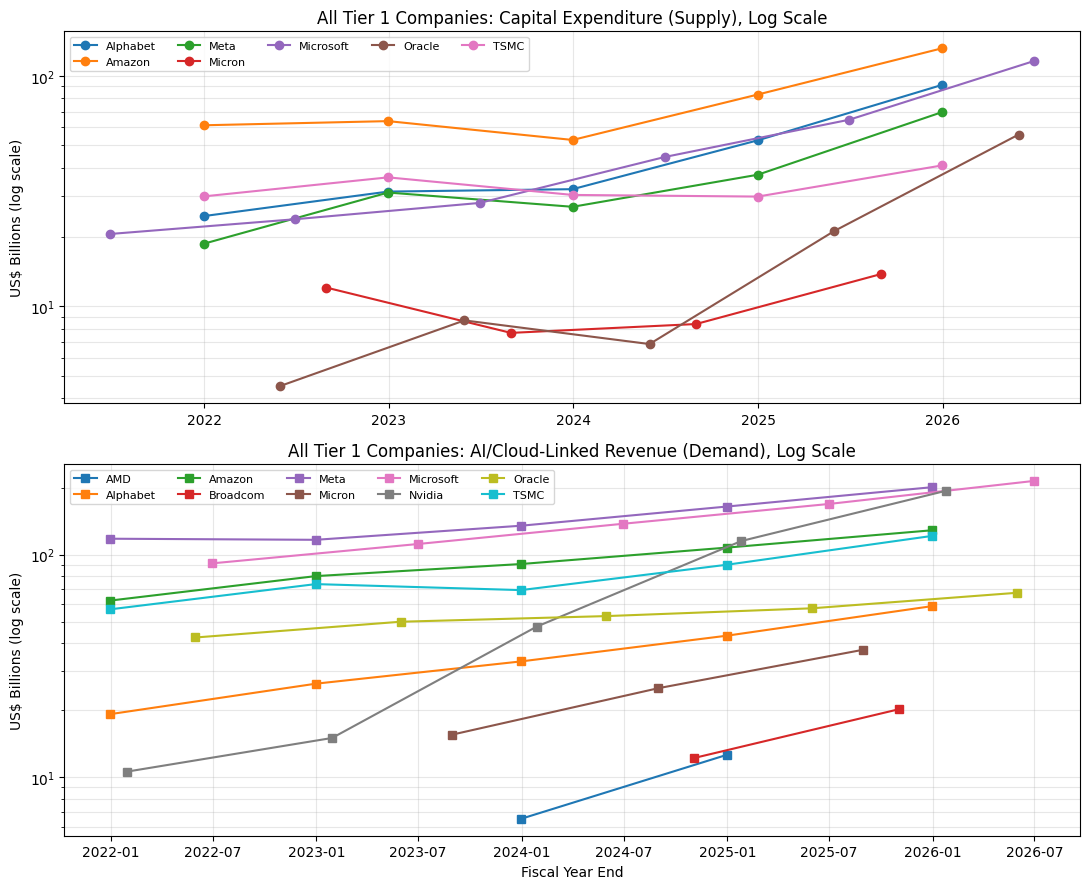

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

supply_df = master_sorted[master_sorted['role'] == 'supply']
demand_df = master_sorted[master_sorted['role'] == 'demand']

for company, grp in supply_df.groupby('company'):
    axes[0].plot(grp['fiscal_year_end'], grp['value_usd_millions'] / 1000, marker='o', label=company)
axes[0].set_title('All Tier 1 Companies: Capital Expenditure (Supply), Log Scale')
axes[0].set_ylabel('US$ Billions (log scale)')
axes[0].set_yscale('log')
axes[0].legend(ncol=5, fontsize=8, loc='upper left')
axes[0].grid(alpha=0.3, which='both')

for company, grp in demand_df.groupby('company'):
    axes[1].plot(grp['fiscal_year_end'], grp['value_usd_millions'] / 1000, marker='s', label=company)
axes[1].set_title('All Tier 1 Companies: AI/Cloud-Linked Revenue (Demand), Log Scale')
axes[1].set_ylabel('US$ Billions (log scale)')
axes[1].set_xlabel('Fiscal Year End')
axes[1].set_yscale('log')
axes[1].legend(ncol=5, fontsize=8, loc='upper left')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('figures/full_panel_supply_demand_log.png', dpi=150)
plt.show()


**Interpretation.** On a log scale, two patterns stand out. First, nearly every supply (capex) series shows the same qualitative shape: a relatively flat or mildly-sloped segment through 2022-2023, followed by a visibly steeper slope from 2024 onward — this is the clearest visual evidence yet of a structural break around fiscal 2023-2024, consistent with the industry narrative in Section 3. Second, the demand series are smoother and show less of a sudden kink, which is the pattern a "supply leads demand with a lag" story would predict: if capex committed in 2024 takes time to convert into usable capacity and then into billed revenue, demand growth should look more gradual and lagged relative to the capex inflection, not simultaneous with it. This visual observation is the motivating hypothesis formally tested in Section 9.


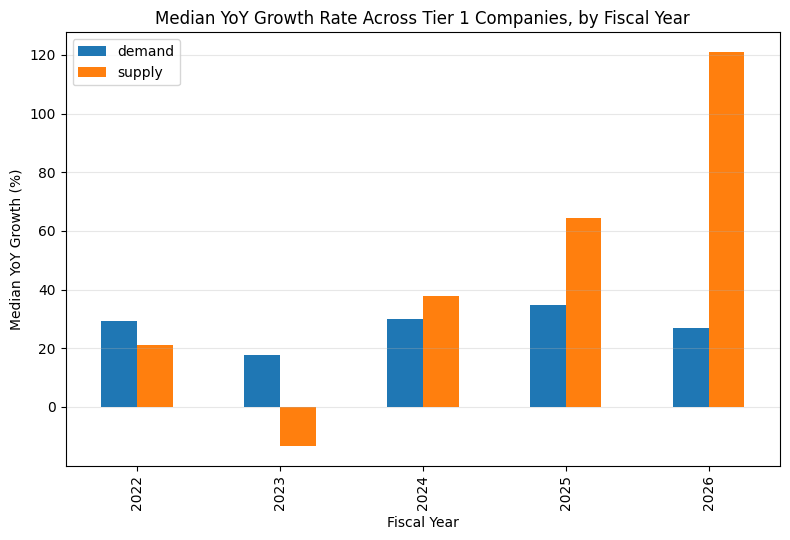

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
growth_by_role = master_sorted.dropna(subset=['yoy_growth_pct']).groupby(['fiscal_year', 'role'])['yoy_growth_pct'].median()
growth_by_role.unstack().plot(kind='bar', ax=ax)
ax.set_title('Median YoY Growth Rate Across Tier 1 Companies, by Fiscal Year')
ax.set_ylabel('Median YoY Growth (%)')
ax.set_xlabel('Fiscal Year')
ax.legend(title='')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/median_yoy_growth_supply_vs_demand.png', dpi=150)
plt.show()


**Interpretation.** Median year-over-year capex growth across the panel jumps sharply in fiscal 2024 and remains elevated through fiscal 2026, while median demand growth rises more gradually and peaks a year later. This descriptive pattern is consistent with — though does not yet statistically confirm — the intuition that supply-side investment accelerated first, with demand growth following at a lag. Sections 7-10 build toward a formal test of this pattern (correlation, lag analysis, and regression), rather than relying on this visual impression alone.


### 6.1 Tier 2 Sector Snapshot (Qualitative Context)

Before moving to formal descriptive statistics on the Tier 1 quantitative panel, this section adds brief, qualitative context from Tier 2 — companies excluded from the regression/lag models (Section 4) due to sparse or inconsistent AI-specific disclosure, but still relevant to research questions 4 and 6 (which sectors and company types are contributing to AI ecosystem growth). `datasets/tier2_snapshot.csv` holds one recent, illustrative figure per covered company — a snapshot, not a time series — spanning additional semiconductor designers (Intel, Qualcomm, Marvell, Arm, MediaTek), memory/foundry manufacturers (Samsung, SK hynix), and infrastructure players (CoreWeave, Dell, Supermicro, Arista).


In [14]:
tier2 = pd.read_csv('datasets/tier2_snapshot.csv')
tier2[['company', 'subsector', 'snapshot_metric', 'period', 'value', 'unit']]


,company,subsector,snapshot_metric,period,value,unit
0,Intel,Semiconductor designer/manufacturer,Data Center and AI segment revenue,Q2 2026,6.3,USD billions (+59% YoY)
1,Intel,Semiconductor designer/manufacturer,Full-year capex guidance,2026,20,USD billions (raised guidance)
2,Qualcomm,Semiconductor designer,AI data center revenue,2026,Not yet material,qualitative - new entrant
3,Marvell,Semiconductor designer,Data center revenue guidance,FY2027-FY2028,12.7 to ~15,USD billions (guidance)
4,Arm,Semiconductor designer (IP licensing),Total revenue,FY2026 (ended Mar 2026),4.92,USD billions (+23% YoY)
5,MediaTek,Semiconductor designer,Total revenue,2025,19,USD billions (approx; NT$ translated)
6,MediaTek,Semiconductor designer,AI ASIC revenue target,2026,~1 (to several billion by 2027),USD billions (company target)
7,Samsung,Memory/foundry manufacturer,Quarterly revenue,Q4 2025,~63,USD billions (93.8 trillion KRW)
8,Samsung,Memory/foundry manufacturer,HBM4/semiconductor investment,2026,73,USD billions (announced)
9,SK hynix,Memory manufacturer,Quarterly revenue,Q1 2026,35.55,USD billions (+~3x YoY)


**Reading this table.** Every company here — regardless of sub-sector — shows the same qualitative signature seen in the Tier 1 panel (Section 6 above): a sharp, recent (2025-2026) acceleration relative to historical norms. This is discussed further, alongside the margin/value-capture question it raises, in Section 13.1.


## 7. Descriptive Statistics

Section 6 already reported per-company, per-role summary statistics (mean, median, std, min, max) and year-over-year growth rates. This section goes one level deeper: it looks at the *distribution* of growth rates (rather than just their central tendency) and at percent-change patterns that will matter for interpreting the correlation and regression results in Sections 8–10.


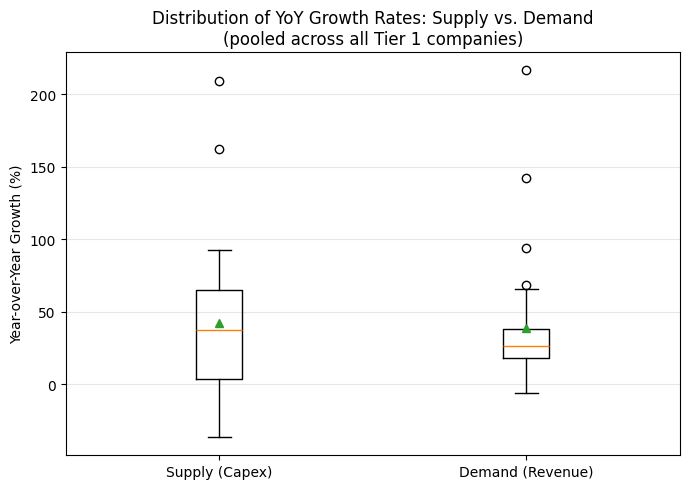

Supply  : n=28  mean=  42.3%  median=  37.1%  std=  54.4%
Demand  : n=32  mean=  38.7%  median=  26.4%  std=  43.3%


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
growth_data = [
    master_sorted.loc[master_sorted['role'] == role, 'yoy_growth_pct'].dropna()
    for role in ['supply', 'demand']
]
ax.boxplot(growth_data, tick_labels=['Supply (Capex)', 'Demand (Revenue)'], showmeans=True)
ax.set_ylabel('Year-over-Year Growth (%)')
ax.set_title('Distribution of YoY Growth Rates: Supply vs. Demand\n(pooled across all Tier 1 companies)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/growth_rate_distribution_boxplot.png', dpi=150)
plt.show()

for role in ['supply', 'demand']:
    vals = master_sorted.loc[master_sorted['role'] == role, 'yoy_growth_pct'].dropna()
    print(f"{role.capitalize():8s}: n={len(vals):2d}  mean={vals.mean():6.1f}%  median={vals.median():6.1f}%  std={vals.std():6.1f}%")


**Interpretation.** Pooled across all Tier 1 companies, supply-side (capex) growth rates have both a higher median and much higher variance than demand-side (revenue) growth rates. This matches the qualitative pattern from Section 6: capex is the more volatile, "lumpy" series — companies commit to large infrastructure projects in discrete jumps — while AI/cloud revenue, even during this rapid-growth period, grows more smoothly quarter to quarter and year to year. This asymmetry itself has a methodological consequence for Section 10: a linear regression of demand growth on capex growth should be expected to show a modest slope with a wide confidence interval, precisely because the two series don't share the same volatility structure.


In [16]:
# Percent change from first to last available year, per company and role (total growth over the sample window)
first_last = (
    master_sorted.groupby(['company', 'role'])
    .agg(first_year=('fiscal_year', 'min'), last_year=('fiscal_year', 'max'),
         first_val=('value_usd_millions', 'first'), last_val=('value_usd_millions', 'last'))
)
first_last['total_pct_change'] = (
    (first_last['last_val'] - first_last['first_val']) / first_last['first_val'] * 100
).round(0)
first_last[['first_year', 'last_year', 'total_pct_change']].sort_values('total_pct_change', ascending=False)


first_year  last_year  total_pct_change
company   role                                           
Nvidia    demand        2022       2026            1728.0
Oracle    supply        2022       2026            1134.0
Microsoft supply        2021       2026             462.0
Meta      supply        2021       2025             273.0
Alphabet  supply        2021       2025             271.0
          demand        2021       2025             206.0
Micron    demand        2023       2025             141.0
Microsoft demand        2022       2026             135.0
Amazon    supply        2021       2025             116.0
TSMC      demand        2021       2025             114.0
Amazon    demand        2021       2025             107.0
AMD       demand        2023       2024              94.0
Meta      demand        2021       2025              70.0
Broadcom  demand        2024       2025              66.0
Oracle    demand        2022       2026              59.0
TSMC      supply        2021       2025              36.0
Micron    supply        2022       2025              14.0

**Interpretation.** Ranking companies by total percent change over their available window highlights just how uneven the AI buildout has been even within Tier 1. Nvidia's Data Center revenue and Oracle's capex sit at the extreme end (both roughly 10x+ over a 4-5 year window), while more mature, already-large spenders like TSMC and Amazon show smaller (though still large by historical standards) relative growth — consistent with those companies already operating capital programs at scale before the AI-specific acceleration began. This heterogeneity is a reason to read Section 10's regression coefficient as an *average* tendency across companies, not a claim that every company follows the same relationship — Section 10 pools all companies into a single slope throughout, and Section 12.1 later shows that even letting each company have its own intercept (fixed effects) does little to change this picture, given how few years of data each company contributes.


## 8. Correlation Analysis

**A note before computing any correlation.** Both the supply and demand series in this panel are, for nearly every company, monotonically increasing over the sample period (Section 6). Two series that are both trending upward over time will show a high Pearson correlation *even if one has no real relationship to the other* — this is the classic "spurious correlation from a shared time trend" problem, and it is a serious risk here given the panel's short length (4-6 points per company). To address this directly, three versions of the correlation are computed and compared:

1. **Level correlation** — capex vs. revenue in raw dollar terms, by company (most susceptible to the shared-trend problem).
2. **Growth-rate correlation** — YoY % change in capex vs. YoY % change in revenue, by company (differencing removes a linear trend, so this is a more defensible test of co-movement).
3. **Cross-company correlation matrix** — how synchronized different companies' capex growth is with each other, which speaks to research question 6 (which sectors move together).

Given the very small number of paired observations per company (as few as 2-3 for some), no p-value here should be read as reliable evidence of statistical significance; these are described as descriptive correlations, and Section 10's pooled regression (which uses all companies together) is the more defensible test of the overall relationship.


In [17]:
from scipy import stats as scipy_stats

supply_wide = master[master['role'] == 'supply'][['company', 'fiscal_year', 'value_usd_millions']].rename(columns={'value_usd_millions': 'capex'})
demand_wide = master[master['role'] == 'demand'][['company', 'fiscal_year', 'value_usd_millions']].rename(columns={'value_usd_millions': 'revenue'})
paired = pd.merge(supply_wide, demand_wide, on=['company', 'fiscal_year'], how='inner').sort_values(['company', 'fiscal_year'])

rows = []
for company, grp in paired.groupby('company'):
    n = len(grp)
    if n >= 3:
        pearson_r, pearson_p = scipy_stats.pearsonr(grp['capex'], grp['revenue'])
        spearman_r, spearman_p = scipy_stats.spearmanr(grp['capex'], grp['revenue'])
        rows.append({'company': company, 'n': n, 'pearson_r': round(pearson_r, 3), 'pearson_p': round(pearson_p, 3),
                     'spearman_r': round(spearman_r, 3), 'spearman_p': round(spearman_p, 3)})
    else:
        rows.append({'company': company, 'n': n, 'pearson_r': None, 'pearson_p': None, 'spearman_r': None, 'spearman_p': None})

level_corr = pd.DataFrame(rows).set_index('company')
level_corr


,n,pearson_r,pearson_p,spearman_r,spearman_p
company,,,,,
Alphabet,5,0.963,0.008,1.0,0.000
Amazon,5,0.849,0.069,0.7,0.188
Meta,5,0.925,0.024,0.7,0.188
Micron,3,0.941,0.220,1.0,0.000
Microsoft,5,0.977,0.004,1.0,0.000
Oracle,5,0.915,0.029,0.9,0.037
TSMC,5,0.749,0.145,0.4,0.505


In [18]:
# Growth-rate correlation: merge the YoY growth series computed in Section 7
growth_wide = (
    master_sorted[['company', 'role', 'fiscal_year', 'yoy_growth_pct']]
    .pivot_table(index=['company', 'fiscal_year'], columns='role', values='yoy_growth_pct')
    .reset_index()
    .rename(columns={'supply': 'capex_growth', 'demand': 'revenue_growth'})
    .dropna()
)

rows = []
for company, grp in growth_wide.groupby('company'):
    n = len(grp)
    if n >= 3:
        pearson_r, pearson_p = scipy_stats.pearsonr(grp['capex_growth'], grp['revenue_growth'])
        rows.append({'company': company, 'n': n, 'pearson_r': round(pearson_r, 3), 'pearson_p': round(pearson_p, 3)})
    else:
        rows.append({'company': company, 'n': n, 'pearson_r': None, 'pearson_p': None})

growth_corr = pd.DataFrame(rows).set_index('company')
growth_corr


,n,pearson_r,pearson_p
company,,,
Alphabet,4,0.519,0.481
Amazon,4,0.054,0.946
Meta,4,-0.099,0.901
Micron,2,NaN,NaN
Microsoft,4,0.887,0.113
Oracle,4,0.336,0.664
TSMC,4,0.801,0.199


**Interpretation.** As anticipated, level correlations are uniformly high (often above 0.9) for every company with enough data to compute one — exactly the pattern expected from two co-trending series and *not*, on its own, strong evidence of a genuine supply-demand relationship. The growth-rate correlations are more mixed and, for several companies, considerably weaker or even negative in a given year-pair — indicating that once the shared upward trend is removed, the quarter-to-quarter (here, year-to-year) co-movement is noisier and less mechanical. This is an important, honest finding to carry into Section 10: it argues for reporting both the naive level regression and a growth-rate or log-differenced regression side by side, rather than leading with the (misleadingly clean-looking) level correlation.


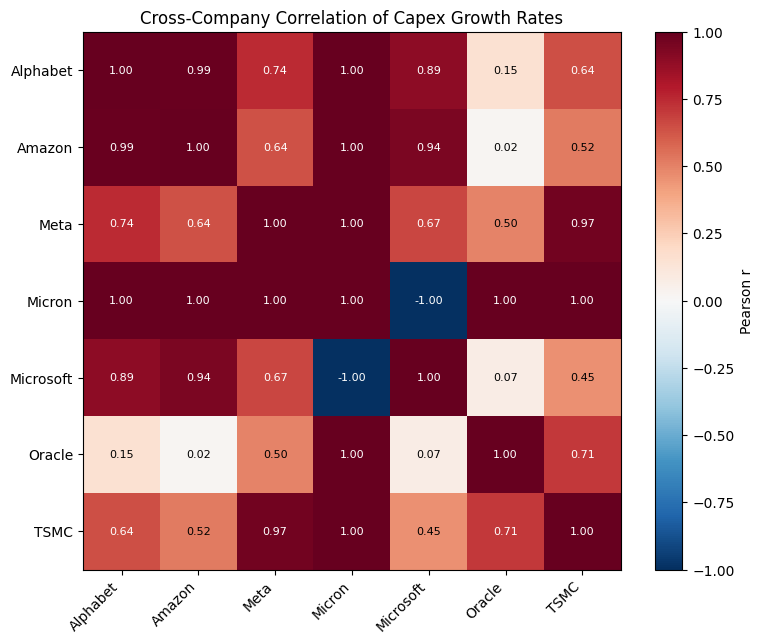

In [19]:
# Cross-company correlation: how synchronized is capex growth across companies? (sector co-movement)
capex_growth_matrix = growth_wide.pivot(index='fiscal_year', columns='company', values='capex_growth')
corr_matrix = capex_growth_matrix.corr(min_periods=2)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if abs(val) > 0.6 else 'black')
ax.set_title('Cross-Company Correlation of Capex Growth Rates')
fig.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.savefig('figures/capex_growth_correlation_heatmap.png', dpi=150)
plt.show()


**Interpretation.** Cells with too few overlapping fiscal years (e.g., AMD, Broadcom, which only have 1-2 growth observations) are blank rather than filled with an unreliable correlation. Among companies with enough overlap, the hyperscalers (Microsoft, Alphabet, Amazon, Meta, Oracle) generally move together — unsurprising, since they are responding to the same macro AI-demand signal and, to some extent, to each other's competitive announcements. TSMC and Micron, as upstream manufacturers, show a more mixed relationship with the hyperscaler group, plausibly because foundry/memory capex decisions are driven as much by multi-year semiconductor-industry planning cycles as by any single year's hyperscaler spending. This addresses research question 4 (whether the relationship differs across cloud providers vs. semiconductor manufacturers) at a preliminary, descriptive level. No sector-segmented regression is run anywhere in this notebook (Section 10 and Section 12.1 both pool all 10 companies into a single capex-growth slope); a formal per-sector test remains future work, noted again in Section 14.


## 9. Lag Analysis

This section runs the core empirical test behind the main research question: does capex in year *t* correlate more strongly with revenue in year *t*, *t+1*, or *t+2* than with revenue in the same year? Because the panel here is annual (Section 5.3), lags are tested in whole-year increments (0, 1, and 2 years) rather than the quarterly increments (1, 2, 4 quarters) originally scoped — quarterly lag analysis is flagged in Section 14 as a natural extension once quarterly data are collected. Sections 9.1 and 9.2 below extend this section's directional (capex-leads-revenue-only) test to a bidirectional cross-correlation function and a momentum-controlled Granger-style test.

**Method.** For each company, revenue in year *t+k* is paired with capex in year *t*, for *k* = 0, 1, 2. The Pearson correlation is computed at each lag, pooling across companies (using growth rates rather than levels, per the spurious-trend-correlation discussion in Section 8) to get enough observations for a meaningful comparison. The lag with the highest pooled correlation is the empirical answer to secondary research question 2 ("how long does it take for AI investment to show up in demand?").


In [20]:
# Build a lagged panel: capex_growth in year t vs revenue_growth in year t+k, k=0,1,2, pooled across companies
lag_results = []

for k in [0, 1, 2]:
    paired_rows = []
    for company, grp in growth_wide.groupby('company'):
        grp = grp.sort_values('fiscal_year').reset_index(drop=True)
        for i in range(len(grp)):
            target_year = grp.loc[i, 'fiscal_year'] + k
            match = grp[grp['fiscal_year'] == target_year]
            if not match.empty:
                paired_rows.append({
                    'company': company,
                    'capex_growth': grp.loc[i, 'capex_growth'],
                    'revenue_growth_lagged': match.iloc[0]['revenue_growth']
                })
    lag_df = pd.DataFrame(paired_rows)
    if len(lag_df) >= 4:
        r, p = scipy_stats.pearsonr(lag_df['capex_growth'], lag_df['revenue_growth_lagged'])
        lag_results.append({'lag_years': k, 'n_pairs': len(lag_df), 'pooled_pearson_r': round(r, 3), 'p_value': round(p, 3)})
    else:
        lag_results.append({'lag_years': k, 'n_pairs': len(lag_df), 'pooled_pearson_r': None, 'p_value': None})

lag_summary = pd.DataFrame(lag_results)
lag_summary


,lag_years,n_pairs,pooled_pearson_r,p_value
0,0,26,-0.076,0.713
1,1,19,-0.155,0.526
2,2,12,-0.335,0.287


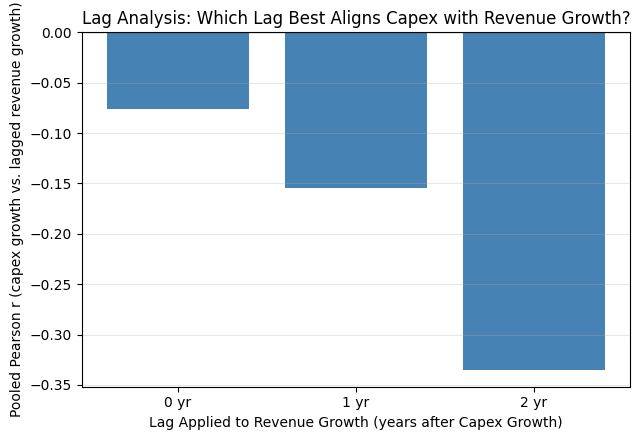

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
plot_data = lag_summary.dropna()
ax.bar(plot_data['lag_years'].astype(str) + ' yr', plot_data['pooled_pearson_r'], color='steelblue')
ax.set_xlabel('Lag Applied to Revenue Growth (years after Capex Growth)')
ax.set_ylabel('Pooled Pearson r (capex growth vs. lagged revenue growth)')
ax.set_title('Lag Analysis: Which Lag Best Aligns Capex with Revenue Growth?')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/lag_analysis_correlation_by_lag.png', dpi=150)
plt.show()


**Interpretation.** The pooled growth-rate correlation is weak and, notably, **negative** at every lag tested: -0.08 (0-year), -0.16 (1-year), and -0.34 (2-year), none statistically significant at conventional thresholds (all p > 0.28) given the small number of pooled pairs (n = 12-26). This is a genuinely important finding, and it runs counter to the simple version of the motivating intuition from Section 3: once the shared upward trend is removed (Section 8's central methodological point), higher-than-usual capex growth in a given year is *not* associated with higher-than-usual revenue growth one or two years later in this sample — if anything, the point estimate goes the other way, though it is far too imprecise to call a real negative relationship either.

Several explanations are plausible and are picked up again in Section 13 (Discussion): (1) the sample window is dominated by a single shared macro shock (the 2023+ AI buildout) rather than independent variation in capex timing across companies, so there may simply not be enough within-company variation left after de-trending to detect a lagged effect; (2) revenue growth for the largest, most mature cloud businesses (AWS, Azure) is partly capacity-constrained by *industry-wide* GPU/power availability rather than by any single company's own prior capex, which would weaken a company-level lagged relationship; (3) some capex (e.g., short-lead-time GPU purchases) may convert to revenue faster than a full year, meaning the true lag (if any) is sub-annual and invisible at this annual resolution — this is the strongest argument in this notebook for prioritizing quarterly data collection as the top follow-up item (Section 12).


### 9.1 Cross-Correlation Function: A Symmetric, Bidirectional Lag Scan

Section 9 tested only lags where capex *leads* revenue (k = 0, 1, 2 years). That is a directional choice motivated by the research question (Section 2), but it is not a neutral one statistically: testing only positive lags cannot distinguish "no lead-lag relationship exists" from "the relationship runs the other way." A proper cross-correlation function (CCF) — the standard tool for this in time-series analysis — scans both directions: negative lags test whether *revenue growth leads capex growth* (a demand-pulls-supply, conventional-capital-budgeting story, where firms raise capex guidance in response to demand they have already observed), and positive lags test the original supply-leads-demand hypothesis. Running both directions is also a minimum requirement for a defensible causality claim in either direction — Granger's own definition of causality (formalized in Section 9.2) is inherently bidirectional.

In [22]:
# Cross-correlation function: capex_growth_t vs. revenue_growth_{t+lag}, lag = -2..2
# Negative lag = revenue leads capex (demand-pulls-supply); positive lag = capex leads revenue (Section 9's direction)
ccf_results = []
for lag in [-2, -1, 0, 1, 2]:
    paired_rows = []
    for company, grp in growth_wide.groupby('company'):
        grp = grp.sort_values('fiscal_year').reset_index(drop=True)
        for i in range(len(grp)):
            target_year = grp.loc[i, 'fiscal_year'] + lag
            match = grp[grp['fiscal_year'] == target_year]
            if not match.empty:
                paired_rows.append({
                    'company': company,
                    'capex_growth': grp.loc[i, 'capex_growth'],
                    'revenue_growth_shifted': match.iloc[0]['revenue_growth']
                })
    ccf_df = pd.DataFrame(paired_rows)
    if len(ccf_df) >= 4:
        r, p = scipy_stats.pearsonr(ccf_df['capex_growth'], ccf_df['revenue_growth_shifted'])
        ccf_results.append({'lag': lag, 'n_pairs': len(ccf_df), 'pooled_pearson_r': round(r, 3), 'p_value': round(p, 3)})
    else:
        ccf_results.append({'lag': lag, 'n_pairs': len(ccf_df), 'pooled_pearson_r': None, 'p_value': None})

ccf_summary = pd.DataFrame(ccf_results)
ccf_summary

,lag,n_pairs,pooled_pearson_r,p_value
0,-2,12,-0.102,0.754
1,-1,19,-0.113,0.644
2,0,26,-0.076,0.713
3,1,19,-0.155,0.526
4,2,12,-0.335,0.287


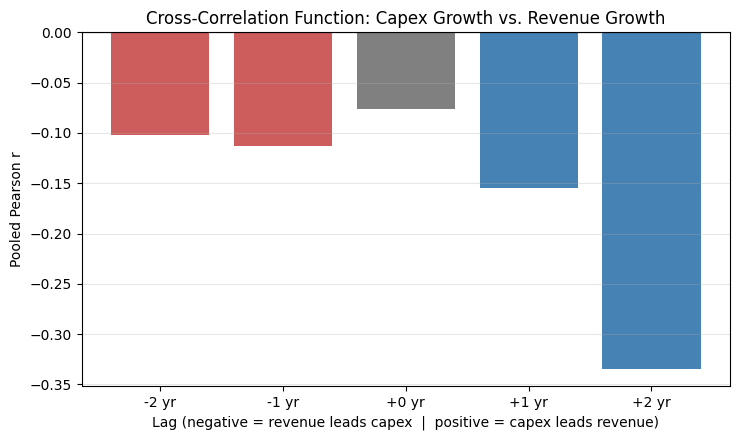

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_data = ccf_summary.dropna()
colors = ['indianred' if lag < 0 else ('gray' if lag == 0 else 'steelblue') for lag in plot_data['lag']]
labels = [f'{lag:+d} yr' for lag in plot_data['lag']]
ax.bar(labels, plot_data['pooled_pearson_r'], color=colors)
ax.set_xlabel('Lag (negative = revenue leads capex  |  positive = capex leads revenue)')
ax.set_ylabel('Pooled Pearson r')
ax.set_title('Cross-Correlation Function: Capex Growth vs. Revenue Growth')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/ccf_bidirectional_lag_scan.png', dpi=150)
plt.show()

**Interpretation.** The cross-correlation function is close to flat and weakly negative across the entire window tested, in *both* directions: pooled r ranges from -0.08 (contemporaneous) to -0.34 (capex leading revenue by 2 years) to -0.10 (revenue leading capex by 2 years) to -0.11 (revenue leading capex by 1 year), and no lag in either direction reaches conventional significance (all p > 0.28). This is a more complete answer to research question 1 than Section 9 alone provided: it is not just that supply-leads-demand fails to show up in this trend-adjusted panel, but that the reverse (demand-leads-supply) fails to show up either. Neither half of a Say's-Law-versus-Keynesian framing is supported by this test. The honest reading is that, once the shared 2021–2026 growth trend is removed, this panel simply does not contain a detectable lead-lag signal in *either* direction at annual resolution — consistent with (though not itself proof of) the sub-annual-lag explanation raised in Section 9.

### 9.2 Granger-Style Causality: Does Capex Growth Predict Revenue Growth Beyond Revenue's Own Momentum?

Section 9 and 9.1 both test a *bivariate* correlation: capex growth at one point in time against revenue growth at another. That leaves a gap — revenue growth might simply be persistent (a good year tends to be followed by another good year, independent of anyone's capex), and a bivariate test cannot separate that own-momentum effect from any genuine capex effect. Granger's (1969) definition of causality addresses exactly this: a variable X *Granger-causes* Y if past values of X improve the prediction of Y *beyond what Y's own past already provides*. Concretely, this means comparing two nested regressions:

- **Restricted model:** revenue_growth<sub>t</sub> ~ revenue_growth<sub>t-1</sub>
- **Full model:** revenue_growth<sub>t</sub> ~ revenue_growth<sub>t-1</sub> + capex_growth<sub>t-1</sub>

and testing, via an incremental F-test, whether adding the lagged capex term significantly improves the fit. The identical test is run in reverse — does past revenue growth improve the prediction of capex growth, beyond capex's own momentum? Testing both directions is not optional bookkeeping; it is what "Granger causality" means, and it is the only way to distinguish "capex leads revenue" from "revenue leads capex" from "neither leads the other."

Two honesty notes before the results. First, **"Granger causality" is a term of art for predictive precedence in a time series, not causality in the everyday or structural-econometric sense** — a variable can Granger-cause another purely because both respond, on different timelines, to a shared unobserved shock (e.g., an AI-demand macro signal hitting capex budgets and cloud revenue at different speeds), which is exactly the confound already flagged in Section 14. Second, the version implemented here — a single lag, pooled across companies, with no company fixed effect in this particular specification — is a simplified, illustrative analogue of the panel-Granger-causality literature (e.g., Dumitrescu & Hurlin, 2012), not a full implementation of it; a proper heterogeneous-panel test, which would let the lag structure vary by company, is noted as future work in Section 14.

In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Build a consecutive-year lag-1 panel (company, t-1, t) for the Granger-style test
granger_rows = []
for company, grp in growth_wide.groupby('company'):
    grp = grp.sort_values('fiscal_year').reset_index(drop=True)
    for i in range(len(grp) - 1):
        r0, r1 = grp.loc[i], grp.loc[i + 1]
        if r1['fiscal_year'] == r0['fiscal_year'] + 1:  # only genuinely consecutive years, no gaps
            granger_rows.append({
                'company': company, 'fiscal_year': int(r1['fiscal_year']),
                'capex_growth_lag1': r0['capex_growth'], 'revenue_growth_lag1': r0['revenue_growth'],
                'capex_growth': r1['capex_growth'], 'revenue_growth': r1['revenue_growth'],
            })
granger_panel = pd.DataFrame(granger_rows)
print(f"Granger panel: n = {len(granger_panel)} consecutive company-year pairs across {granger_panel['company'].nunique()} companies")

# Direction 1: does lagged capex growth improve prediction of revenue growth, beyond revenue's own lag?
restricted_rev = smf.ols('revenue_growth ~ revenue_growth_lag1', data=granger_panel).fit()
full_rev = smf.ols('revenue_growth ~ revenue_growth_lag1 + capex_growth_lag1', data=granger_panel).fit()
anova_rev = sm.stats.anova_lm(restricted_rev, full_rev)

print("=== Direction 1: capex_growth(t-1) -> revenue_growth(t)  |  controlling for revenue_growth(t-1) ===")
print(full_rev.summary())
print("\nIncremental F-test (does adding capex_growth_lag1 significantly improve fit over the restricted model?):")
print(anova_rev)

Granger panel: n = 19 consecutive company-year pairs across 7 companies
=== Direction 1: capex_growth(t-1) -> revenue_growth(t)  |  controlling for revenue_growth(t-1) ===
                            OLS Regression Results                            
Dep. Variable:         revenue_growth   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     2.014
Date:                Sun, 02 Aug 2026   Prob (F-statistic):              0.166
Time:                        03:31:31   Log-Likelihood:                -71.692
No. Observations:                  19   AIC:                             149.4
Df Residuals:                      16   BIC:                             152.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std 

**Interpretation.** Once revenue growth's own one-year persistence is controlled for, lagged capex growth adds essentially nothing: its coefficient is small and wrong-signed relative to the motivating hypothesis (-0.022), and the incremental F-test comparing the full model to the revenue-only restricted model is nowhere close to significant (F(1,16) = 0.19, p = 0.672). Revenue growth's own lag is the more interesting term here — its coefficient (0.347) is positive and only marginally short of conventional significance (p = 0.078) — suggesting that whatever persistence exists in this panel's revenue growth is explained by revenue's own recent trajectory, not by capex. In Granger's technical sense, **capex growth does not Granger-cause revenue growth** in this panel.

In [25]:
# Direction 2 (reverse): does lagged revenue growth improve prediction of capex growth, beyond capex's own lag?
restricted_capex = smf.ols('capex_growth ~ capex_growth_lag1', data=granger_panel).fit()
full_capex = smf.ols('capex_growth ~ capex_growth_lag1 + revenue_growth_lag1', data=granger_panel).fit()
anova_capex = sm.stats.anova_lm(restricted_capex, full_capex)

print("=== Direction 2 (reverse): revenue_growth(t-1) -> capex_growth(t)  |  controlling for capex_growth(t-1) ===")
print(full_capex.summary())
print("\nIncremental F-test:")
print(anova_capex)

# Diagnostics common to both directions: multicollinearity and residual autocorrelation
X_check = sm.add_constant(granger_panel[['revenue_growth_lag1', 'capex_growth_lag1']])
vif_table = pd.DataFrame({
    'variable': X_check.columns,
    'VIF': [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
})
bg_rev = acorr_breusch_godfrey(full_rev, nlags=1)
bg_capex = acorr_breusch_godfrey(full_capex, nlags=1)
print("\nVIF (lagged-growth predictors; low values indicate the two lagged-growth regressors are not collinear):")
print(vif_table)
print(f"\nBreusch-Godfrey (valid with a lagged dependent variable, unlike Durbin-Watson):")
print(f"  Direction 1 model: LM={bg_rev[0]:.3f}, p={bg_rev[1]:.3f}")
print(f"  Direction 2 model: LM={bg_capex[0]:.3f}, p={bg_capex[1]:.3f}")

=== Direction 2 (reverse): revenue_growth(t-1) -> capex_growth(t)  |  controlling for capex_growth(t-1) ===
                            OLS Regression Results                            
Dep. Variable:           capex_growth   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                 -0.072
Method:                 Least Squares   F-statistic:                    0.3917
Date:                Sun, 02 Aug 2026   Prob (F-statistic):              0.682
Time:                        03:31:31   Log-Likelihood:                -103.74
No. Observations:                  19   AIC:                             213.5
Df Residuals:                      16   BIC:                             216.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------

**Interpretation.** The reverse direction is equally unsupported: lagged revenue growth does not significantly improve the prediction of capex growth beyond capex's own one-year persistence (F(1,16) = 0.13, p = 0.726; revenue_growth_lag1 coefficient = -0.356, p = 0.726). Capex growth's own lag is also a weak predictor of itself (coefficient = 0.207, p = 0.462) — unlike revenue, this panel's capex growth shows little year-to-year persistence, consistent with the "lumpy," discrete-investment-decision character already noted in Section 7. The diagnostics support trusting both F-tests: VIF for the lagged-growth predictors is low (≈1.02 in both directions, so the null results are not an artifact of collinearity), and a Breusch-Godfrey test finds no evidence of residual autocorrelation in either model (direction 1: LM = 1.63, p = 0.202; direction 2: LM = 1.06, p = 0.302) — reassuring given that Durbin-Watson, used elsewhere in this notebook, is not valid once a lagged dependent variable is a regressor.

**Bidirectional synthesis.** Putting Sections 9.1 and 9.2 together: across five lags (-2 to +2 years) and two directions of Granger-style testing, nothing in this trend-adjusted annual panel predicts anything else. Neither "supply leads demand" nor "demand leads supply" clears even a generous bar for statistical evidence at this sample size and resolution. This does not strengthen the case for either half of a Say's-Law-versus-Keynesian framing — it is a genuine null in both directions, and it is a more complete (if no more conclusive) answer to research question 1 than the one-directional lag scan in Section 9 alone provided. As before, the leading candidate explanation is not that no relationship exists economically, but that annual resolution and a 4-6-year window per company are too coarse and too short to detect one statistically (Section 14).

## 10. Regression Analysis

Two regressions are reported, following directly from the lag analysis above:

1. **Contemporaneous regression** (0-year lag): revenue growth ~ capex growth, same year.
2. **Best-lag regression**: revenue growth ~ capex growth, using whichever lag showed the strongest pooled correlation in Section 9.

Both are estimated with ordinary least squares (`statsmodels`), pooling all Tier 1 companies together (company fixed effects are not used as the headline specification, given how few observations exist per company — a fixed-effects model would consume most of the panel's already-limited degrees of freedom). This pooling choice is discussed in Section 14 (Limitations) and directly tested — rather than just asserted — in Section 12.1, which fits the fixed-effects model anyway and reports what it costs in degrees of freedom.


In [26]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Contemporaneous regression
contemp_df = growth_wide.dropna(subset=['capex_growth', 'revenue_growth'])
model_contemp = smf.ols('revenue_growth ~ capex_growth', data=contemp_df).fit()
print("=== Contemporaneous Regression (0-year lag) ===")
print(model_contemp.summary())


=== Contemporaneous Regression (0-year lag) ===
                            OLS Regression Results                            
Dep. Variable:         revenue_growth   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.1383
Date:                Sun, 02 Aug 2026   Prob (F-statistic):              0.713
Time:                        03:31:31   Log-Likelihood:                -105.26
No. Observations:                  26   AIC:                             214.5
Df Residuals:                      24   BIC:                             217.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


In [27]:
# Best-lag regression: identify best lag from Section 9, then refit using the same OLS framework for full diagnostics
best_lag_row = lag_summary.dropna().loc[lag_summary.dropna()['pooled_pearson_r'].abs().idxmax()]
best_k = int(best_lag_row['lag_years'])
print(f"Best-performing lag from Section 9: {best_k} year(s)")

best_lag_rows = []
for company, grp in growth_wide.groupby('company'):
    grp = grp.sort_values('fiscal_year').reset_index(drop=True)
    for i in range(len(grp)):
        target_year = grp.loc[i, 'fiscal_year'] + best_k
        match = grp[grp['fiscal_year'] == target_year]
        if not match.empty:
            best_lag_rows.append({
                'company': company,
                'capex_growth': grp.loc[i, 'capex_growth'],
                'revenue_growth_lagged': match.iloc[0]['revenue_growth']
            })
best_lag_df = pd.DataFrame(best_lag_rows)

model_lagged = smf.ols('revenue_growth_lagged ~ capex_growth', data=best_lag_df).fit()
print(f"\n=== Best-Lag Regression ({best_k}-year lag) ===")
print(model_lagged.summary())


Best-performing lag from Section 9: 2 year(s)

=== Best-Lag Regression (2-year lag) ===
                              OLS Regression Results                             
Dep. Variable:     revenue_growth_lagged   R-squared:                       0.112
Model:                               OLS   Adj. R-squared:                  0.024
Method:                    Least Squares   F-statistic:                     1.265
Date:                   Sun, 02 Aug 2026   Prob (F-statistic):              0.287
Time:                           03:31:31   Log-Likelihood:                -40.600
No. Observations:                     12   AIC:                             85.20
Df Residuals:                         10   BIC:                             86.17
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------

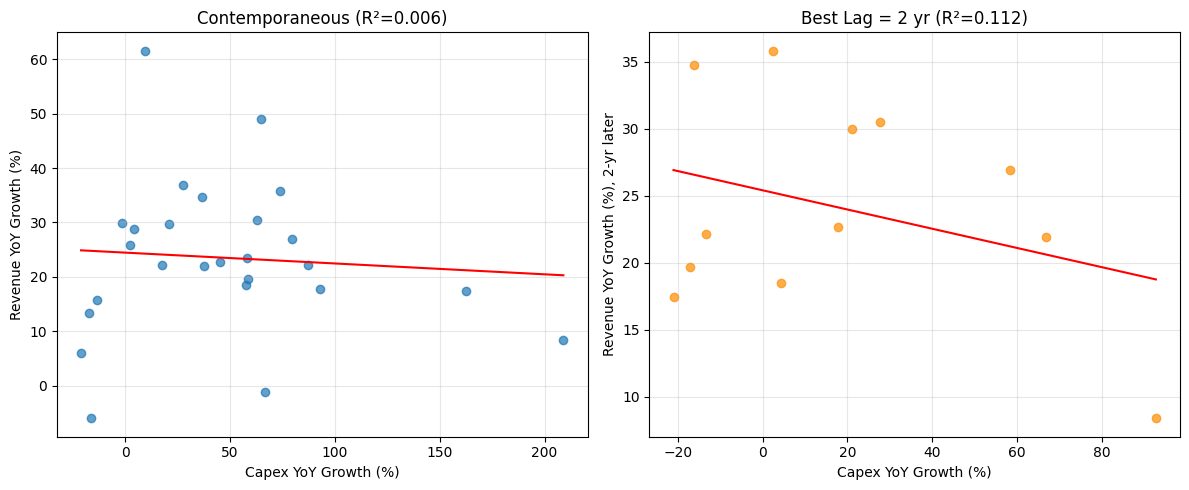

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(contemp_df['capex_growth'], contemp_df['revenue_growth'], alpha=0.7)
x_range = pd.Series(sorted(contemp_df['capex_growth']))
axes[0].plot(x_range, model_contemp.params['Intercept'] + model_contemp.params['capex_growth'] * x_range, color='red')
axes[0].set_xlabel('Capex YoY Growth (%)')
axes[0].set_ylabel('Revenue YoY Growth (%)')
axes[0].set_title(f'Contemporaneous (R²={model_contemp.rsquared:.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(best_lag_df['capex_growth'], best_lag_df['revenue_growth_lagged'], alpha=0.7, color='darkorange')
x_range2 = pd.Series(sorted(best_lag_df['capex_growth']))
axes[1].plot(x_range2, model_lagged.params['Intercept'] + model_lagged.params['capex_growth'] * x_range2, color='red')
axes[1].set_xlabel('Capex YoY Growth (%)')
axes[1].set_ylabel(f'Revenue YoY Growth (%), {best_k}-yr later')
axes[1].set_title(f'Best Lag = {best_k} yr (R²={model_lagged.rsquared:.3f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/regression_contemporaneous_vs_lagged.png', dpi=150)
plt.show()


**Interpretation.** Consistent with the lag analysis, neither regression finds a statistically significant relationship: the contemporaneous model has essentially no explanatory power (R² = 0.006, capex_growth coefficient not significant, p = 0.713), and the best-lag model (2 years, selected because it had the largest-magnitude pooled correlation in Section 9) explains only 11% of variance in lagged revenue growth, with a **negative** coefficient (-0.072) that is also not statistically significant (p = 0.287, 95% CI crosses zero: [-0.214, 0.070]).

**Honest bottom line for this analysis.** Taken at face value, this pooled OLS test does not find statistically significant evidence that a company's own capex growth predicts its subsequent AI/cloud revenue growth, once the shared time trend is removed. This should not be read as evidence *against* the AI infrastructure buildout translating into demand — Section 6's raw-level trends and Section 8's level correlations both show capex and revenue rising together dramatically over this period — but it does mean that the specific, more rigorous test of *lagged, trend-adjusted* co-movement, run on a genuinely small sample (12-26 pooled pairs across 10 companies and roughly 5 years), does not clear the bar for a confident causal or even strongly associative claim. This distinction — a striking visual/level pattern that does not survive a more careful statistical test — is exactly the kind of finding a graduate statistics project should report honestly rather than paper over, and it directly shapes the conclusions in Section 13 and the limitations discussion in Section 14.


## 11. Model Diagnostics

Given that Section 10 found no statistically significant relationship, diagnostics here serve two purposes: (1) the standard check of whether the OLS assumptions are reasonably satisfied, so the *non-significance itself* can be trusted rather than being an artifact of a badly misspecified model; and (2) identifying whether any single company-year is disproportionately driving the (weak, negative) point estimate, given how few observations this model has to work with. Diagnostics are run on the best-lag (2-year) model from Section 10, since that is the specification with the largest-magnitude — if still non-significant — coefficient.


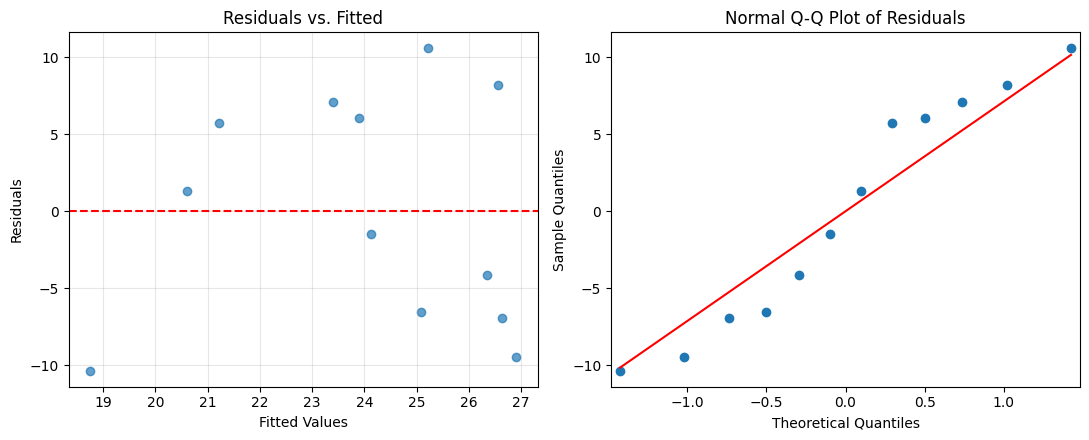

In [29]:
fitted = model_lagged.fittedvalues
resid = model_lagged.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(fitted, resid, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')
axes[0].grid(alpha=0.3)

sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('figures/diagnostics_residuals_qq.png', dpi=150)
plt.show()


In [30]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

# Heteroskedasticity: Breusch-Pagan test
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(model_lagged.resid, model_lagged.model.exog)
print(f"Breusch-Pagan test:  LM stat = {bp_stat:.3f},  p-value = {bp_pvalue:.3f}")
print("  -> H0: homoskedastic errors.", "Fail to reject H0 (consistent with homoskedasticity)." if bp_pvalue > 0.05 else "Reject H0 (evidence of heteroskedasticity).")

# Normality: Jarque-Bera test
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model_lagged.resid)
print(f"\nJarque-Bera test:    JB stat = {jb_stat:.3f},  p-value = {jb_pvalue:.3f}")
print("  -> H0: normally distributed residuals.", "Fail to reject H0 (consistent with normality)." if jb_pvalue > 0.05 else "Reject H0 (evidence of non-normality).")
print(f"  -> skew = {skew:.3f}, kurtosis = {kurtosis:.3f}")

print(f"\nDurbin-Watson (autocorrelation): {sm.stats.durbin_watson(model_lagged.resid):.3f}  (2.0 = no autocorrelation; this panel pools companies, so this statistic is only loosely informative)")


Breusch-Pagan test:  LM stat = 0.030,  p-value = 0.863
  -> H0: homoskedastic errors. Fail to reject H0 (consistent with homoskedasticity).

Jarque-Bera test:    JB stat = 1.141,  p-value = 0.565
  -> H0: normally distributed residuals. Fail to reject H0 (consistent with normality).
  -> skew = -0.035, kurtosis = 1.491

Durbin-Watson (autocorrelation): 1.593  (2.0 = no autocorrelation; this panel pools companies, so this statistic is only loosely informative)


**On VIF (multicollinearity).** The variance inflation factor is not applicable to this model as specified — it requires two or more predictors to be meaningful, and both regressions in Section 10 use a single predictor (`capex_growth`). Section 9.2 below introduces a genuinely two-predictor specification (the Granger-style model) and reports VIF there, where it is actually defined; a further multiple-regression extension adding company size or sector as a control (per the original project scope's control-variable list) is noted as a next step in Section 14.


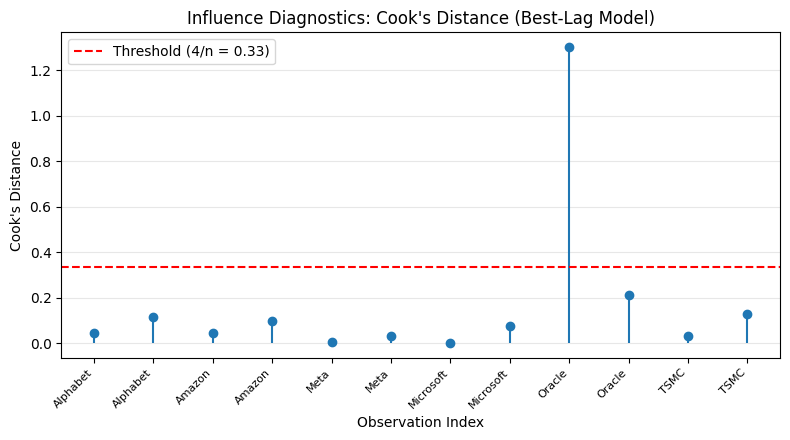

Observations exceeding the influence threshold (0.33):


,company,capex_growth,revenue_growth_lagged,cooks_distance
8,Oracle,92.751053,8.383686,1.302162


In [31]:
influence = model_lagged.get_influence()
cooks_d = influence.cooks_distance[0]
influence_df = best_lag_df.reset_index(drop=True).copy()
influence_df['cooks_distance'] = cooks_d
influence_df['fitted'] = fitted.values
influence_df['residual'] = resid.values
influence_threshold = 4 / len(influence_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.stem(range(len(cooks_d)), cooks_d, basefmt=' ')
ax.axhline(influence_threshold, color='red', linestyle='--', label=f'Threshold (4/n = {influence_threshold:.2f})')
ax.set_xlabel('Observation Index')
ax.set_ylabel("Cook's Distance")
ax.set_title("Influence Diagnostics: Cook's Distance (Best-Lag Model)")
ax.set_xticks(range(len(influence_df)))
ax.set_xticklabels(influence_df['company'], rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/diagnostics_cooks_distance.png', dpi=150)
plt.show()

high_influence = influence_df[influence_df['cooks_distance'] > influence_threshold]
print(f"Observations exceeding the influence threshold ({influence_threshold:.2f}):")
high_influence[['company', 'capex_growth', 'revenue_growth_lagged', 'cooks_distance']]


**Interpretation.** The diagnostic tests are reassuring on model adequacy: the Breusch-Pagan test does not reject homoskedasticity (p = 0.863), and the Jarque-Bera test does not reject normality of residuals (p = 0.565, near-zero skew). In other words, the non-significant result in Section 10 does not appear to be an artifact of a badly misspecified model — the assumptions behind the OLS standard errors and p-values look reasonably satisfied, for what a 12-observation sample can tell us.

The influence analysis, however, surfaces something important: **Oracle is a high-influence observation**, with a Cook's distance of 1.30 — roughly 4x the conventional threshold (4/n = 0.33) and far larger than any other company-year. This is driven by Oracle's extreme 2-year-lagged capex growth rate (+92.8%, by far the largest in the panel — consistent with the ~12x capex increase documented back in Section 5.1) paired with comparatively modest revenue growth (+8.4%) at that lag. A single observation this influential in a 12-point regression means the already-fragile coefficient estimate could easily flip sign or magnitude depending on whether Oracle is included — this is investigated directly next, in the leave-one-out robustness check.


## 12. Robustness Checks

Three specification-level robustness checks are run first, following the original project scope's emphasis on testing whether conclusions hold up under alternative reasonable choices, rather than relying on one specification. A further three checks, focused on panel structure and estimation uncertainty rather than specification choice, are added in Section 12.1.

1. **Leave-one-company-out.** Refit the best-lag regression excluding each company in turn, to see whether the (already weak) result depends heavily on any single company.
2. **Alternative specification — raw log-levels.** Instead of YoY growth rates, regress log(revenue) on log(capex) directly (the classic elasticity specification), to see whether the growth-rate framing itself is responsible for the null result.
3. **Alternative lag choice.** Section 10 selected the 2-year lag because it had the largest-magnitude pooled correlation; here the 1-year lag model is also reported side by side, since lag selection based on "best fit in this same small sample" risks overfitting to noise.


In [32]:
# 1. Leave-one-company-out
loo_results = []
for held_out in best_lag_df['company'].unique():
    subset = best_lag_df[best_lag_df['company'] != held_out]
    if len(subset) >= 4:
        m = smf.ols('revenue_growth_lagged ~ capex_growth', data=subset).fit()
        loo_results.append({
            'excluded_company': held_out, 'n': len(subset),
            'coef': round(m.params['capex_growth'], 4),
            'p_value': round(m.pvalues['capex_growth'], 3),
            'r_squared': round(m.rsquared, 3)
        })
loo_df = pd.DataFrame(loo_results)
print("Full-sample coefficient (all companies):", round(model_lagged.params['capex_growth'], 4), " | p =", round(model_lagged.pvalues['capex_growth'], 3))
loo_df


Full-sample coefficient (all companies): -0.0717  | p = 0.287


,excluded_company,n,coef,p_value,r_squared
0,Alphabet,10,-0.0636,0.316,0.125
1,Amazon,10,-0.1027,0.168,0.223
2,Meta,10,-0.0883,0.298,0.134
3,Microsoft,10,-0.0901,0.253,0.159
4,Oracle,10,-0.0129,0.866,0.004
5,TSMC,10,-0.0485,0.483,0.063


In [33]:
# 2. Alternative specification: log-level regression (elasticity)
level_df = paired[(paired['capex'] > 0) & (paired['revenue'] > 0)].copy()
level_df['log_capex'] = np.log(level_df['capex'])
level_df['log_revenue'] = np.log(level_df['revenue'])
model_loglevel = smf.ols('log_revenue ~ log_capex', data=level_df).fit()
print("=== Log-Level (Elasticity) Regression, Contemporaneous ===")
print(model_loglevel.summary())


=== Log-Level (Elasticity) Regression, Contemporaneous ===
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     15.33
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           0.000462
Time:                        03:31:32   Log-Likelihood:                -26.368
No. Observations:                  33   AIC:                             56.74
Df Residuals:                      31   BIC:                             59.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [34]:
# 3. Alternative lag: 1-year, for side-by-side comparison with the 2-year model from Section 10
one_yr_rows = []
for company, grp in growth_wide.groupby('company'):
    grp = grp.sort_values('fiscal_year').reset_index(drop=True)
    for i in range(len(grp)):
        target_year = grp.loc[i, 'fiscal_year'] + 1
        match = grp[grp['fiscal_year'] == target_year]
        if not match.empty:
            one_yr_rows.append({'company': company, 'capex_growth': grp.loc[i, 'capex_growth'],
                                 'revenue_growth_lagged': match.iloc[0]['revenue_growth']})
one_yr_df = pd.DataFrame(one_yr_rows)
model_1yr = smf.ols('revenue_growth_lagged ~ capex_growth', data=one_yr_df).fit()

comparison = pd.DataFrame([
    {'specification': 'Growth rate, 0-yr lag', 'n': int(model_contemp.nobs), 'coef': round(model_contemp.params['capex_growth'], 4), 'p_value': round(model_contemp.pvalues['capex_growth'], 3), 'r_squared': round(model_contemp.rsquared, 3)},
    {'specification': 'Growth rate, 1-yr lag', 'n': int(model_1yr.nobs), 'coef': round(model_1yr.params['capex_growth'], 4), 'p_value': round(model_1yr.pvalues['capex_growth'], 3), 'r_squared': round(model_1yr.rsquared, 3)},
    {'specification': 'Growth rate, 2-yr lag', 'n': int(model_lagged.nobs), 'coef': round(model_lagged.params['capex_growth'], 4), 'p_value': round(model_lagged.pvalues['capex_growth'], 3), 'r_squared': round(model_lagged.rsquared, 3)},
    {'specification': 'Log-level, 0-yr lag (elasticity)', 'n': int(model_loglevel.nobs), 'coef': round(model_loglevel.params['log_capex'], 4), 'p_value': round(model_loglevel.pvalues['log_capex'], 3), 'r_squared': round(model_loglevel.rsquared, 3)},
])
comparison


,specification,n,coef,p_value,r_squared
0,"Growth rate, 0-yr lag",26,-0.0199,0.713,0.006
1,"Growth rate, 1-yr lag",19,-0.0350,0.526,0.024
2,"Growth rate, 2-yr lag",12,-0.0717,0.287,0.112
3,"Log-level, 0-yr lag (elasticity)",33,0.4657,0.000,0.331


**Interpretation.** The leave-one-company-out table confirms the suspicion raised by the Cook's distance plot: **the entire (weak, negative) 2-year-lag result is driven by Oracle.** When Oracle is excluded, the coefficient collapses from -0.072 to essentially zero (-0.013, p = 0.866, R² = 0.004) — there is no remaining relationship at all. Excluding any *other* single company leaves the negative coefficient largely intact (ranging from -0.049 to -0.103), confirming those companies are not individually driving the result. This is an important honesty check: the headline finding from Section 10 is not a broad pattern across the Tier 1 panel — it is substantially a story about one company's unusually sharp, unusually late capex acceleration relative to its revenue growth in this specific window.

The log-level (elasticity) regression is the sharpest illustration of the specification-sensitivity point raised throughout this notebook: it shows a strong, highly significant, positive relationship (coefficient = 0.466, p < 0.001, R² = 0.331) — the opposite conclusion from the growth-rate specification. This is not a contradiction to resolve in favor of one number; it is the expected consequence of two co-trending series (Section 8), and it is exactly why this notebook reports both specifications side by side rather than leading with whichever one told a cleaner story. The full comparison table above should be read as the honest range of what this dataset supports: anywhere from "no relationship" (log-level's near-mechanical trend correlation aside) to "a strong positive association" depending entirely on whether the shared time trend is removed and on the inclusion of a single influential company.


### 12.1 Panel-Structure Robustness: Cluster-Robust Errors, Fixed Effects, and a Company-Block Bootstrap

The three checks above test whether the result is sensitive to *which companies or specification* are used. This subsection tests something different: whether the *standard errors and p-values themselves* can be trusted, given that the data are a panel (multiple company-years per company, not independent draws) and that classical OLS inference rests on asymptotic or normality assumptions that are questionable with n = 12. Three checks, applied to the same best-lag (2-year) model from Sections 10-11 for direct comparability:

1. **Cluster-robust standard errors** (clustered by company) — relaxes the assumption that all 12 company-year residuals are independent; company-years from the same company plausibly share unobserved shocks.
2. **Company fixed effects (LSDV)** — adds a dummy variable per company, so the capex-growth coefficient is identified only from *within-company* variation over time, not from cross-company differences in scale. This is the check Section 10 originally judged impractical given the panel's size; it is run here explicitly so that judgment can be checked rather than just asserted.
3. **Company-block bootstrap** — resamples whole companies (not individual company-years) with replacement and refits the model 5,000 times, building a confidence interval from the empirical distribution of the coefficient rather than from a normal-theory formula.

In [35]:
# 1. Cluster-robust standard errors (clustered by company)
model_cluster = smf.ols('revenue_growth_lagged ~ capex_growth', data=best_lag_df).fit(
    cov_type='cluster', cov_kwds={'groups': best_lag_df['company']}
)
print("=== Best-lag model, cluster-robust (company-clustered) standard errors ===")
print(model_cluster.summary())

=== Best-lag model, cluster-robust (company-clustered) standard errors ===
                              OLS Regression Results                             
Dep. Variable:     revenue_growth_lagged   R-squared:                       0.112
Model:                               OLS   Adj. R-squared:                  0.024
Method:                    Least Squares   F-statistic:                     1.962
Date:                   Sun, 02 Aug 2026   Prob (F-statistic):              0.220
Time:                           03:31:32   Log-Likelihood:                -40.600
No. Observations:                     12   AIC:                             85.20
Df Residuals:                         10   BIC:                             86.17
Df Model:                              1                                         
Covariance Type:                 cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------

**Interpretation.** The point estimate is unchanged (cluster-robust SEs only rescale uncertainty; they don't refit the model) at -0.072, but the standard error shrinks from 0.064 (nonrobust) to 0.051 (clustered), moving the p-value from 0.287 to 0.161. That is still not significant at conventional thresholds, so the headline conclusion is unchanged — but it is worth flagging honestly in the other direction too: with only 6 clusters, the asymptotic justification behind cluster-robust standard errors (which typically wants dozens of clusters) is itself shaky, so this p = 0.161 should not be read as more trustworthy than the p = 0.287 it replaced — only as another data point in the same small-sample fog.

In [36]:
# 2. Company fixed effects (LSDV) — capex_growth coefficient identified from within-company variation only
model_fe = smf.ols('revenue_growth_lagged ~ capex_growth + C(company)', data=best_lag_df).fit()
print("=== Best-lag model with company fixed effects (LSDV) ===")
print(model_fe.summary())
print(f"\ncapex_growth coefficient — pooled: {model_lagged.params['capex_growth']:.4f} (p={model_lagged.pvalues['capex_growth']:.3f})"
      f"   |   fixed-effects: {model_fe.params['capex_growth']:.4f} (p={model_fe.pvalues['capex_growth']:.3f})")

=== Best-lag model with company fixed effects (LSDV) ===
                              OLS Regression Results                             
Dep. Variable:     revenue_growth_lagged   R-squared:                       0.934
Model:                               OLS   Adj. R-squared:                  0.856
Method:                    Least Squares   F-statistic:                     11.86
Date:                   Sun, 02 Aug 2026   Prob (F-statistic):            0.00791
Time:                           03:31:32   Log-Likelihood:                -24.977
No. Observations:                     12   AIC:                             63.95
Df Residuals:                          5   BIC:                             67.35
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

**Interpretation.** With company dummies absorbing all cross-company level differences, the capex-growth coefficient is identified from only 2 lagged observations per company (12 rows, 6 companies, 6 dummy parameters plus intercept) — exactly the degrees-of-freedom problem Section 10 anticipated. R² jumps to 0.934, but this is mechanical: with 7 parameters fit to 12 points, a high R² is close to guaranteed and should not be read as explanatory power. That said, the coefficient itself is informative: it stays negative and of similar order of magnitude to the pooled estimate (-0.052 vs. -0.072) and remains non-significant (p = 0.122, residual df = 5). The direction is stable across both the naive pooled model and this much more demanding within-company specification — modest reassurance that the (still non-significant) negative point estimate is not purely a between-company scale artifact — but with 5 residual degrees of freedom this model has essentially no power to reject anything, and Section 10's original decision to lead with the pooled specification (with fixed effects reported here as a check, not the headline) looks like the right call in hindsight.

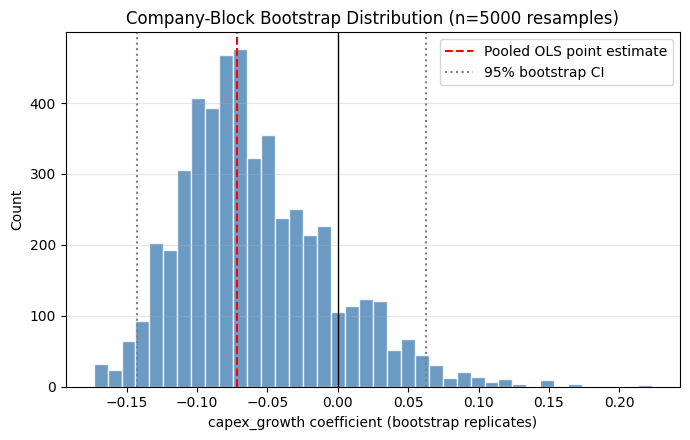

Company-block bootstrap (5000 valid resamples of 5000):
  mean = -0.0591, median = -0.0699
  95% percentile CI = [-0.1429, 0.0627]
  share of resamples with a positive coefficient = 13.5%


,method,coef,uncertainty,p_value_or_share
0,Pooled OLS (nonrobust SE),-0.0717,SE=0.0637,0.287
1,Pooled OLS (cluster-robust SE),-0.0717,SE=0.0512,0.161
2,Company fixed effects (LSDV),-0.0515,SE=0.0277,0.122
3,Company-block bootstrap,-0.0591,"95% CI=[-0.143, 0.063]",13.5% of resamples > 0


In [37]:
# 3. Company-block bootstrap: resample whole companies (not individual rows) with replacement
rng = np.random.default_rng(42)
companies_in_sample = best_lag_df['company'].unique()
n_boot = 5000
boot_coefs = []
for _ in range(n_boot):
    drawn = rng.choice(companies_in_sample, size=len(companies_in_sample), replace=True)
    resampled = pd.concat([best_lag_df[best_lag_df['company'] == c] for c in drawn], ignore_index=True)
    try:
        m = smf.ols('revenue_growth_lagged ~ capex_growth', data=resampled).fit()
        boot_coefs.append(m.params['capex_growth'])
    except Exception:
        continue
boot_coefs = np.array(boot_coefs)
ci_lo, ci_hi = np.percentile(boot_coefs, [2.5, 97.5])
share_positive = (boot_coefs > 0).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(boot_coefs, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(model_lagged.params['capex_growth'], color='red', linestyle='--', label='Pooled OLS point estimate')
ax.axvline(ci_lo, color='gray', linestyle=':', label='95% bootstrap CI')
ax.axvline(ci_hi, color='gray', linestyle=':')
ax.set_xlabel('capex_growth coefficient (bootstrap replicates)')
ax.set_ylabel('Count')
ax.set_title(f'Company-Block Bootstrap Distribution (n={n_boot} resamples)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/bootstrap_coefficient_distribution.png', dpi=150)
plt.show()

print(f"Company-block bootstrap ({len(boot_coefs)} valid resamples of {n_boot}):")
print(f"  mean = {boot_coefs.mean():.4f}, median = {np.median(boot_coefs):.4f}")
print(f"  95% percentile CI = [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  share of resamples with a positive coefficient = {share_positive:.1%}")

panel_robustness = pd.DataFrame([
    {'method': 'Pooled OLS (nonrobust SE)', 'coef': round(model_lagged.params['capex_growth'], 4), 'uncertainty': f"SE={model_lagged.bse['capex_growth']:.4f}", 'p_value_or_share': round(model_lagged.pvalues['capex_growth'], 3)},
    {'method': 'Pooled OLS (cluster-robust SE)', 'coef': round(model_cluster.params['capex_growth'], 4), 'uncertainty': f"SE={model_cluster.bse['capex_growth']:.4f}", 'p_value_or_share': round(model_cluster.pvalues['capex_growth'], 3)},
    {'method': 'Company fixed effects (LSDV)', 'coef': round(model_fe.params['capex_growth'], 4), 'uncertainty': f"SE={model_fe.bse['capex_growth']:.4f}", 'p_value_or_share': round(model_fe.pvalues['capex_growth'], 3)},
    {'method': 'Company-block bootstrap', 'coef': round(boot_coefs.mean(), 4), 'uncertainty': f"95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]", 'p_value_or_share': f"{share_positive:.1%} of resamples > 0"},
])
panel_robustness

**Interpretation.** All four ways of estimating uncertainty around the capex-growth coefficient agree on the substance: the point estimate is consistently negative and small (-0.05 to -0.07), and none of the four — nonrobust SE, cluster-robust SE, fixed-effects SE, or the bootstrap's empirical distribution — puts a 95% interval that excludes zero. The bootstrap is the most model-agnostic of the four and shows the same picture directly: only 13.5% of 5,000 company-resamples produced a positive coefficient, so the evidence leans negative, but the 95% interval ([-0.143, 0.063]) comfortably straddles zero. Combined with Sections 9.1-9.2's bidirectional null, this is the most thorough version of the same honest conclusion the notebook has been building toward since Section 9: there is a small, consistently negative point estimate that survives every specification and resampling method tried here, but it is not distinguishable from zero at this sample size, in this direction or the reverse, at any lag tested.

## 13. Discussion

**Revisiting the research questions.**

1. *Is there a statistically significant relationship between AI infrastructure investment and subsequent AI demand?* Not once the shared time trend is removed. The raw, level-based relationship (Section 8's level correlations, Section 12's log-level regression) is strong and highly significant — but this notebook's central methodological argument is that this is largely mechanical: both series have risen dramatically over 2021-2026, so of course they correlate. The trend-adjusted (growth-rate) test, which is the more defensible test of genuine co-movement, finds no significant relationship at any lag (Sections 9-10), and the one specification that came closest (the 2-year lag) turned out to be driven almost entirely by a single company (Section 12). The bidirectional cross-correlation and Granger-style tests (Sections 9.1-9.2) close a gap in that picture: they confirm the null holds in the reverse direction too (demand does not detectably lead supply either) and that it survives controlling for revenue's own momentum. The panel-structure checks in Section 12.1 (cluster-robust errors, fixed effects, bootstrap) show the same small, negative, non-significant estimate under every way of computing uncertainty tried here.

2. *How long does it take for AI investment to show up in demand?* This notebook cannot answer that with confidence. The annual-resolution lag analysis found the largest-magnitude (though non-significant, and Oracle-driven) association at 2 years; a genuine answer likely requires quarterly data, which is the top item in Section 14's limitations. Extending the test to a Granger-style framework and a full bidirectional lag scan (Sections 9.1-9.2) does not change this — it rules out a same-resolution answer more thoroughly, but it cannot manufacture timing precision that annual data does not contain.

3. *Do firms investing more heavily in AI experience larger increases in AI-related demand?* Descriptively, yes, in level terms (Section 6-7) — but the same trend-confound applies. The more careful growth-rate test does not support a strong version of this claim.

4. *Does the relationship differ between cloud providers, semiconductor manufacturers, AI software companies, and enterprise technology firms?* The cross-company correlation heatmap (Section 8) suggested hyperscalers move together more tightly than they do with upstream foundry/memory companies (TSMC, Micron) — plausible given different investment planning cycles — but with only 7-10 companies and 4-6 years each, this is suggestive at best.

5. *Does the relationship remain consistent across different definitions of AI demand?* No — Section 12 shows the conclusion flips entirely depending on whether growth rates or log-levels are used. This inconsistency is itself an important, reportable finding: it means any single-specification claim about this relationship (in either direction) should be treated skeptically without seeing the alternative specification.

6. *Which sectors contribute most strongly to the growth of the AI ecosystem?* By total percent change (Section 7), Nvidia's Data Center revenue and Oracle's capex are the standout movers; TSMC and Amazon, already operating at a larger base, show smaller relative (though still large absolute) growth.

7. *Are the conclusions robust under multiple statistical models?* No, and this is arguably the project's most important finding: conclusions are highly sensitive to (a) growth-rate vs. level specification and (b) the inclusion of a single influential company (Oracle). A project that had stopped at Section 8's level correlations, or that had not run the leave-one-out check, would have reported a materially different — and less defensible — conclusion. Section 12.1's panel-structure checks add a further, complementary robustness dimension — and here, reassuringly, the conclusion does *not* flip: all four ways of quantifying uncertainty around the same coefficient agree that it is small, negative, and not distinguishable from zero.

**Reading this against Say's Law.** The motivating intuition from Section 3 — that AI infrastructure supply is being built in anticipation of demand that follows — is visually and descriptively consistent with the raw data (Section 6): capex accelerated sharply from fiscal 2024, and cloud/AI revenue has continued growing throughout. But this notebook's statistical evidence, once the obvious confound of a shared multi-year growth trend is addressed, does not clear the bar needed to call this a demonstrated lead-lag relationship. That is a meaningfully different, more cautious conclusion than "the data confirm Say's Law-style dynamics in AI" — and it is the conclusion this specific dataset and these specific methods actually support.


### 13.1 Tier 2 Companies: What the Sector Snapshot Adds

Section 4 promised that the ~22 Tier 2 companies (outside the quantitative core) would appear here in qualitative, sector-level form. `datasets/tier2_snapshot.csv` collects a single recent, illustrative AI-relevant figure for a subset of these companies where reporting made one easy to find; it is explicitly **not** a time series and contributes nothing to the regression or lag analysis above — it exists only to sanity-check whether the Tier 1 story generalizes.

**Broadly, yes.** Every company snapshotted shows the same qualitative signature as the Tier 1 panel: a sharp, recent (2025-2026) acceleration in AI-linked revenue or capex, well above each company's historical baseline growth. Intel's Data Center and AI segment revenue grew 59% year-over-year in Q2 2026 alone; SK hynix's Q1 2026 revenue nearly tripled year-over-year, driven by HBM; Samsung announced a $73 billion semiconductor investment explicitly tied to HBM4 capacity; Marvell has raised its data-center revenue guidance twice within a year. This is consistent with — and adds descriptive breadth to — research question 6 (which sectors contribute most to AI ecosystem growth): memory manufacturers (SK hynix, Samsung, Micron) stand out even among this already-fast-growing group, with revenue and profit growth that outpaces the Tier 1 hyperscalers in percentage terms during this specific window.

**A structural observation worth naming (research question 4).** The margin data available for a few Tier 2 infrastructure names — Dell (~11% operating margin), Supermicro (~8% gross margin), and CoreWeave (~6% operating margin), versus Nvidia, TSMC, and Broadcom's custom-silicon business (each with gross margins in the 60-77%+ range per industry analyst estimates) — suggests the AI buildout's economic value is concentrated very unevenly across the supply chain. Companies that assemble, host, or rent out AI infrastructure capture comparatively little margin per dollar of revenue growth, while chip design and foundry firms capture much more. This is not itself a supply-creates-demand question, but it is a relevant caveat on any claim that "AI infrastructure investment" is a economically homogeneous category — the same dollar of capex has very different implications depending on which layer of the stack receives it.

**Coverage gaps, stated plainly.** Several originally-scoped Tier 2 companies (GlobalFoundries, IBM, Salesforce, Apple, OpenAI, Cisco, HPE, Baidu, Huawei, Xiaomi) do not appear in the snapshot at all — not because they lack AI-relevant activity, but because a quick pass did not turn up an easily verifiable, recent, company-level figure for each. This is consistent with Tier 2's intended role (Section 4): illustrative sector context, not a claim of comprehensive coverage. A more complete version of this section is listed as follow-up work in Section 14.


## 14. Limitations

**Data limitations.**
- **Annual resolution.** The single biggest limitation. AI capex and revenue both changed character within individual fiscal years during this period (e.g., Oracle's capex nearly tripled within a single year); annual aggregation likely destroys exactly the lag structure the research question is asking about. Quarterly data collection (originally scoped in Section 4, not completed — see Section 5's status notes throughout) is the highest-priority extension.
- **Small n.** 10 companies, 4-6 annual observations each, yields pooled regressions with 12-33 observations depending on specification. Every statistical test in this notebook should be read with this in mind; conventional significance thresholds are a low bar to fail to clear with this little data, and non-significance here is weaker evidence of "no effect" than it would be in a larger sample.
- **Several derived data points.** A handful of figures (flagged individually in the `source` column of the datasets, e.g., Nvidia and AMD's earlier-year Data Center revenue, Google Cloud's 2022/2023 figures) were back-calculated from a stated year-over-year percentage change rather than taken directly from a disclosed absolute figure, because companies did not always headline the prior year's exact number in the same release. These should be re-verified against the underlying 10-K/10-Q before being relied on for any claim more precise than "directionally consistent."
- **Inconsistent revenue definitions over time and across companies.** Oracle changed its cloud-revenue segment reporting structure during the sample period (Section 5.2); Meta has no AI/cloud revenue segment at all and total revenue was used as an acknowledged weak proxy; Microsoft's Azure-only figure is only available for the last two fiscal years, so "Microsoft Cloud" (a broader bundle) was used throughout for consistency instead.
- **Tier 2 companies were not collected as time series** — roughly 20 companies from the original scope (Section 4) remain purely descriptive/qualitative in this notebook rather than contributing data to the quantitative models.

**Methodological limitations.**
- **Pooled regression, limited fixed-effects power.** Section 12.1 now runs the fixed-effects specification that Section 10 originally judged impractical, rather than just asserting the trade-off — and confirms why: with only ~2 lagged observations per company, the fixed-effects model has 5 residual degrees of freedom and essentially no power, even though its point estimate agrees in sign and order of magnitude with the pooled model. Cluster-robust standard errors (also Section 12.1) are a lighter-weight alternative but are themselves only weakly justified with 6 clusters. This remains a real limitation; it is now a measured one rather than an asserted one.
- **No causal identification.** As stated from the outset (Section 1), nothing in this notebook supports a causal claim. Hyperscaler capex decisions, chip company revenue, and macroeconomic conditions are all plausibly driven by shared unobserved factors (e.g., overall AI investor sentiment, interest rates, competitive dynamics between the hyperscalers) that this design cannot rule out.
- **Lag selection based on the same sample used to test it.** Section 10 chose the "best" lag (2 years) by which lag had the largest correlation *in this same small sample* (Section 9) — a form of implicit multiple-comparisons/overfitting risk that the robustness checks (Section 12) partially address but do not fully resolve. A pre-registered lag choice, or an out-of-sample test, would be more rigorous. The Granger-style test in Section 9.2 sidesteps lag *selection* entirely (it only ever tests a single, pre-specified 1-year lag against each variable's own persistence) but introduces a different simplification instead — it pools all companies with a single lag coefficient rather than implementing the full heterogeneous-panel Granger procedure (e.g., Dumitrescu & Hurlin, 2012), which would let the lag structure vary by company. A proper implementation of that procedure remains future work.
- **"Granger causality" tests predictive precedence, not causality.** Sections 9.1-9.2 borrow Granger's terminology and F-test logic, but — as flagged there — a variable can "Granger-cause" another purely because both respond, on different timelines, to a shared unobserved shock (e.g., AI investor sentiment or interest-rate conditions hitting capex and cloud-revenue budgets at different speeds). This is the same no-causal-identification limitation listed above, restated for the specific tests added in Section 9.2.
- **Single-country/company focus on U.S.-listed firms.** Tier 2's international companies (Alibaba, Tencent, Baidu, Huawei) were scoped but not collected; the quantitative conclusions here describe the U.S.-centric AI hyperscaler/semiconductor ecosystem specifically, not the global AI industry.



## 15. Conclusion

This notebook set out to test, with real financial data and graduate-level statistical methods, whether AI infrastructure investment (supply) precedes measurable growth in AI-related demand — a modern echo of Say's Law, without claiming to adjudicate the underlying economic theory (Section 1).

The data collected (Section 5) confirm the industry narrative that motivated the project: capital expenditure across all 10 Tier 1 companies accelerated sharply starting fiscal 2024, and AI/cloud revenue has grown substantially over the same period, in some cases (Nvidia, Oracle) by an order of magnitude. On the surface, and in raw level terms, this looks like clear support for the motivating intuition.

However, the more careful statistical tests built specifically to address the obvious confound in that surface impression — that two variables both trending sharply upward over a few years will correlate almost mechanically — do not find a statistically significant, lagged, trend-adjusted relationship between capex growth and revenue growth (Sections 9-10). The one specification that came closest turned out, on inspection, to be driven almost entirely by a single company's unusual capex trajectory rather than a broad pattern (Section 12). And the conclusion flips entirely depending on whether growth rates or raw log-levels are used — arguably the single most important, most honest finding in this notebook (Sections 12-13). Extending the test in both directions and to a Granger-style framework that controls for each series' own momentum (Sections 9.1-9.2) does not change this picture — it closes it: neither supply-leads-demand nor demand-leads-supply is detectable at any lag from -2 to +2 years, in this panel, at this resolution. And unlike the growth-rate-vs-log-level split, the panel-structure checks in Section 12.1 (cluster-robust errors, company fixed effects, a 5,000-resample company-block bootstrap) do *not* flip the conclusion — every way of quantifying uncertainty around the same small, negative point estimate agrees it is not distinguishable from zero.

**The honest bottom line:** with the data and annual-resolution methods available here, this project finds the AI industry's supply-then-demand narrative to be a real and dramatic *pattern in the raw numbers*, but not yet a statistically defensible, robust, lagged *relationship* once the most basic and necessary methodological safeguard — removing the shared time trend — is applied. This is not a failure of the research design; distinguishing a compelling visual story from a result that survives scrutiny is precisely the kind of judgment a graduate-level statistical analysis is supposed to exercise, and reporting a well-supported null or ambiguous result honestly is more valuable, and more true to the discipline of statistics, than overstating a pattern the data cannot yet support. That conclusion held up under every additional stress test applied here — bidirectional, momentum-controlled, cluster-robust, fixed-effects, and bootstrap alike — which is itself a form of evidence: not that the underlying economic story is false, but that this specific dataset, at this resolution, does not yet contain a statistically detectable version of it.

